## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'--> outputs logs in: {OUTPUT_PATH}')

--> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Comparison*

In [9]:
def plot_metric_comparison(
    greedy_values,
    bramev_values,
    nb_car_list,
    ylabel,
    title,
    colors,
    scenario_name
):

    x = np.arange(len(nb_car_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2,
        greedy_values,
        width,
        label='Greedy',
        color=colors[0],
        alpha=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        bramev_values,
        width,
        label='BRAMEV',
        color=colors[1],
        alpha=0.8
    )

    scenario_tag = f"[{scenario_name[:3].upper()}]"

    ax.set_title(
        f'{scenario_tag} {title}',
        fontweight='bold'
    )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(nb_car_list)
    ax.set_xlabel('Number of Cars')

    ax.legend()

    max_value = max(
        max(greedy_values),
        max(bramev_values)
    )

    if max_value > 0:
        ax.set_ylim(0, 1.15 * max_value)

    # Valeurs sur les barres
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01 * max_value,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# 1. Exact Satisfaction
# =========================================================

def plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        exact_satif_greedy_list,
        exact_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Exact Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 2. Needs Satisfaction
# =========================================================

def plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        needs_satif_greedy_list,
        needs_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Needs Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 3. Mean Travel Distance
# =========================================================

def plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_travel_greedy_list,
        mean_travel_bramev_list,
        nb_car_list,
        ylabel='Distance (km)',
        title='Mean Travel Distance (km)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 4. Mean Waiting Time
# =========================================================

def plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_waiting_greedy_list,
        mean_waiting_bramev_list,
        nb_car_list,
        ylabel='Waiting Time (min)',
        title='Mean Waiting Time (min)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 5. Mean Response Time
# =========================================================

def plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_response_greedy_list,
        mean_response_bramev_list,
        nb_car_list,
        ylabel='Response Time (ms)',
        title='Mean Response Time (ms)',
        colors=colors,
        scenario_name=scenario_name
    )
    

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [10]:
SCENARIO = 'balance'

BASE_CAR_BEHAVIOR = {
    'pres': 60,     # présent et honore la réservation
    'abs': 20,      # no-show complet
    'early': 12,    # annulation anticipée (> 2h avant)
    'late': 8,      # annulation tardive (< 2h avant)
    'noise': 0.10
}

In [11]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance


In [12]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [13]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [14]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [15]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/greedy/50cars


##### *Initialisation*

In [16]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [17]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:31:43.449 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-30 16:31:43.454 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-30 16:31:43.567 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-30 16:31:43.681 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-30 16:31:43.777 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-30 16:31:43.885 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-30 16:31:43.905 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-30 16:31:43.991 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-30 16:31:44.062 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-30 16:31:44.137 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-30 16:31:44.279 | IN

##### *Metrics*

In [18]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 13.99 kWh
  Station 1: 15.82 kWh
  Station 2: 1.29 kWh
  Station 3: 0.00 kWh
  Station 4: 9.82 kWh
  Station 5: 1.53 kWh
  Station 6: 0.00 kWh
  Station 7: 18.74 kWh
  Station 8: 2.27 kWh
  Station 9: 1.67 kWh
  Station 10: 87.94 kWh
  Station 11: 2.05 kWh
  Station 12: 0.00 kWh
  Station 13: 0.00 kWh
  Station 14: 0.00 kWh
  Station 15: 2.00 kWh
  Station 16: 4.62 kWh
  Station 17: 4.03 kWh
  Station 18: 6.23 kWh
  Station 19: 25.52 kWh
  Station 20: 7.97 kWh
  Station 21: 17.65 kWh
  Station 22: 30.48 kWh
  Station 23: 19.67 kWh
  Station 24: 18.32 kWh
  Station 25: 3.50 kWh
  Station 26: 4.46 kWh
  Station 27: 4.84 kWh
  Station 28: 86.76 kWh
  Station 29: 1.20 kWh
  Station 30: 5.78 kWh
  Station 31: 1.46 kWh
  Station 32: 11.78 kWh
  Station 33: 9.05 kWh
  Station 34: 56.14 kWh
  Station 35: 1.47 kWh
  Station 36: 16.57 kWh
  Station 37: 0.00 kWh
  Station 38: 5.93 kWh
  Station 39: 66.90 kWh

--- User Req

In [19]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

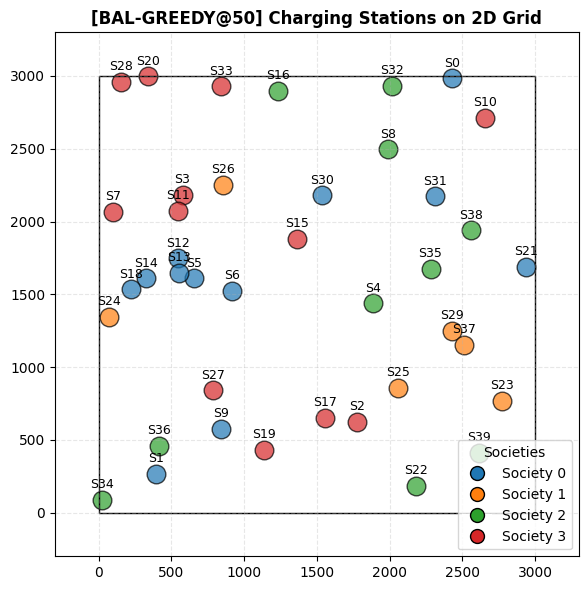

In [20]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

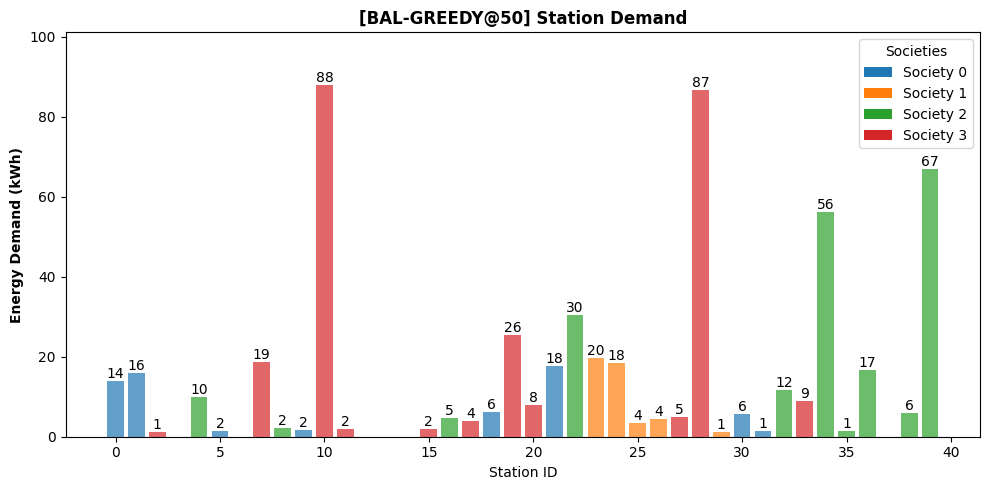

In [21]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

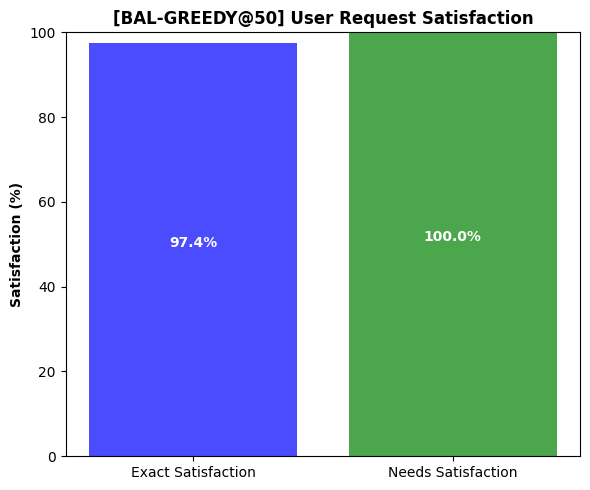

In [22]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

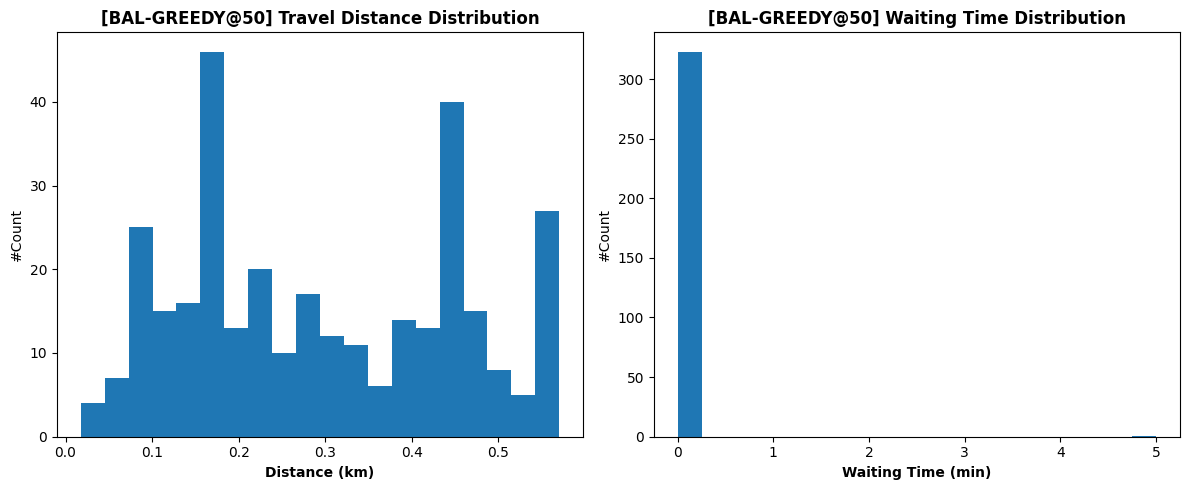

In [23]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

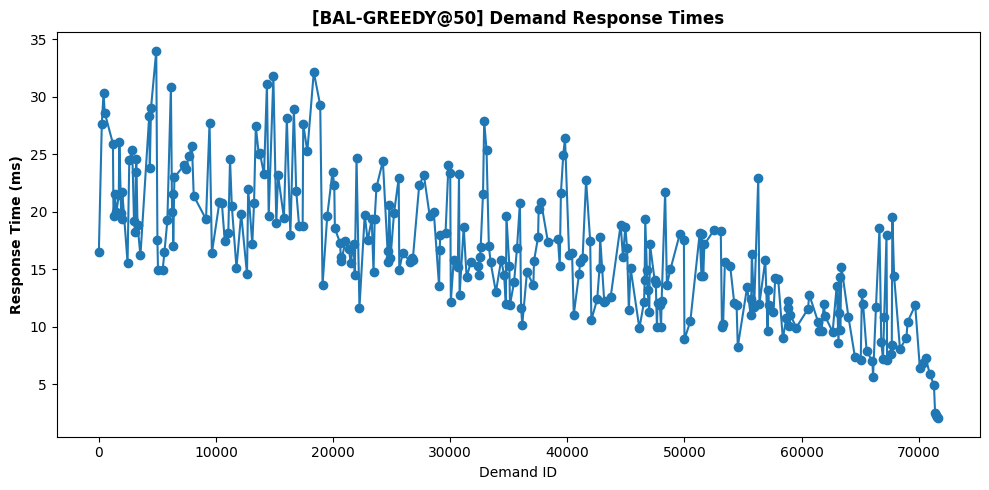

In [24]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

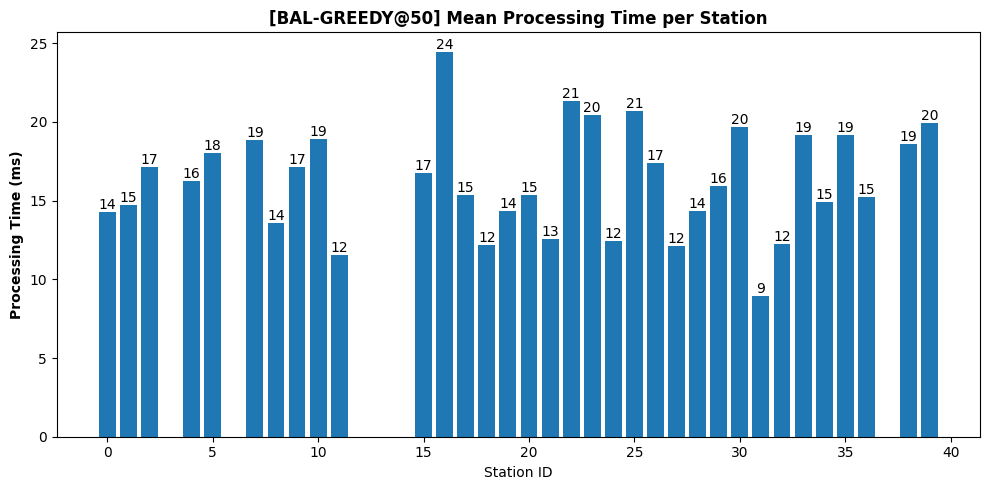

In [25]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [26]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/bramev/50cars


##### *Initialisation*

In [27]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [28]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:31:50.927 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-30 16:31:50.932 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-30 16:31:51.155 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-30 16:31:51.931 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-30 16:31:52.204 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-30 16:31:52.733 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-30 16:31:53.195 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-30 16:31:53.358 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-30 16:31:53.702 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-30 16:31:54.112 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-30 16:31:54.721 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [29]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 2.33 kWh
  Station 1: 26.26 kWh
  Station 2: 5.73 kWh
  Station 3: 26.68 kWh
  Station 4: 34.06 kWh
  Station 5: 13.35 kWh
  Station 6: 69.94 kWh
  Station 7: 0.00 kWh
  Station 8: 8.37 kWh
  Station 9: 1.67 kWh
  Station 10: 7.99 kWh
  Station 11: 12.35 kWh
  Station 12: 24.53 kWh
  Station 13: 17.01 kWh
  Station 14: 73.86 kWh
  Station 15: 0.00 kWh
  Station 16: 0.00 kWh
  Station 17: 15.92 kWh
  Station 18: 5.50 kWh
  Station 19: 6.38 kWh
  Station 20: 2.10 kWh
  Station 21: 1.10 kWh
  Station 22: 7.98 kWh
  Station 23: 2.58 kWh
  Station 24: 5.38 kWh
  Station 25: 11.94 kWh
  Station 26: 35.12 kWh
  Station 27: 9.30 kWh
  Station 28: 0.00 kWh
  Station 29: 5.47 kWh
  Station 30: 0.00 kWh
  Station 31: 31.50 kWh
  Station 32: 50.62 kWh
  Station 33: 4.08 kWh
  Station 34: 2.30 kWh
  Station 35: 0.00 kWh
  Station 36: 0.00 kWh
  Station 37: 9.75 kWh
  Station 38: 11.73 kWh
  Station 39: 4.13 kWh

--- User Re

In [30]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

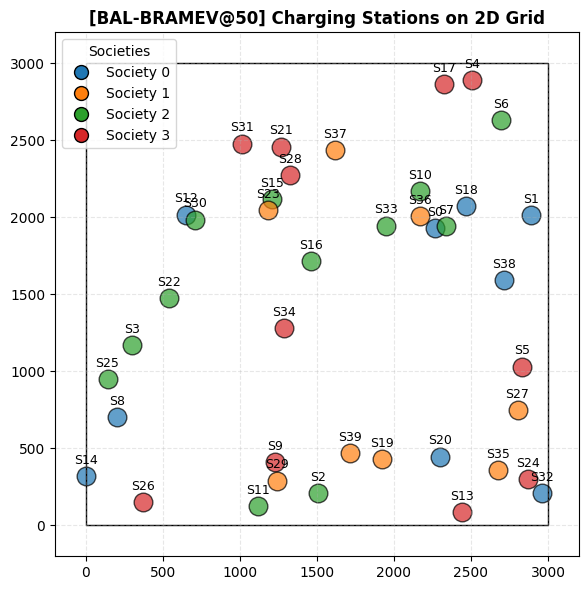

In [31]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

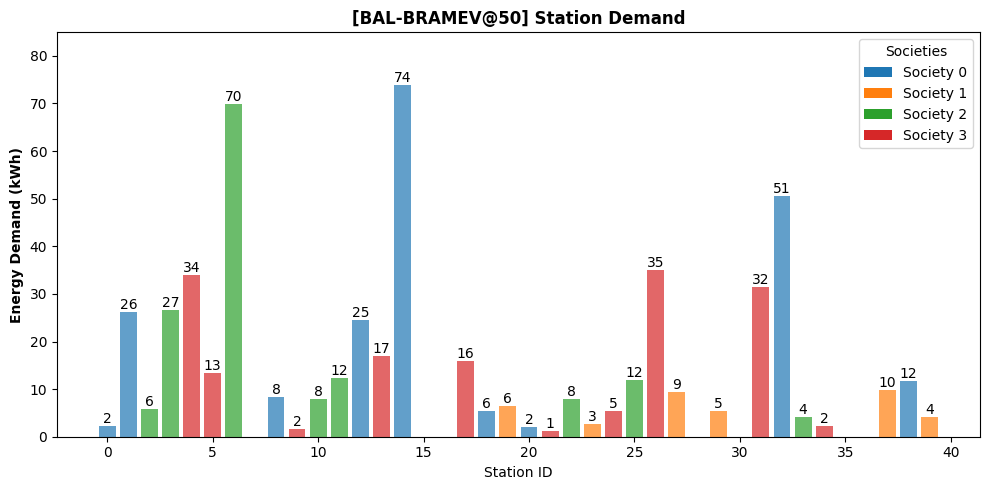

In [32]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

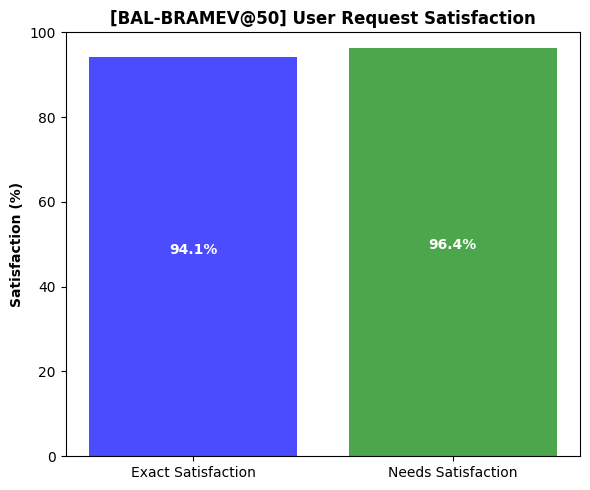

In [33]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

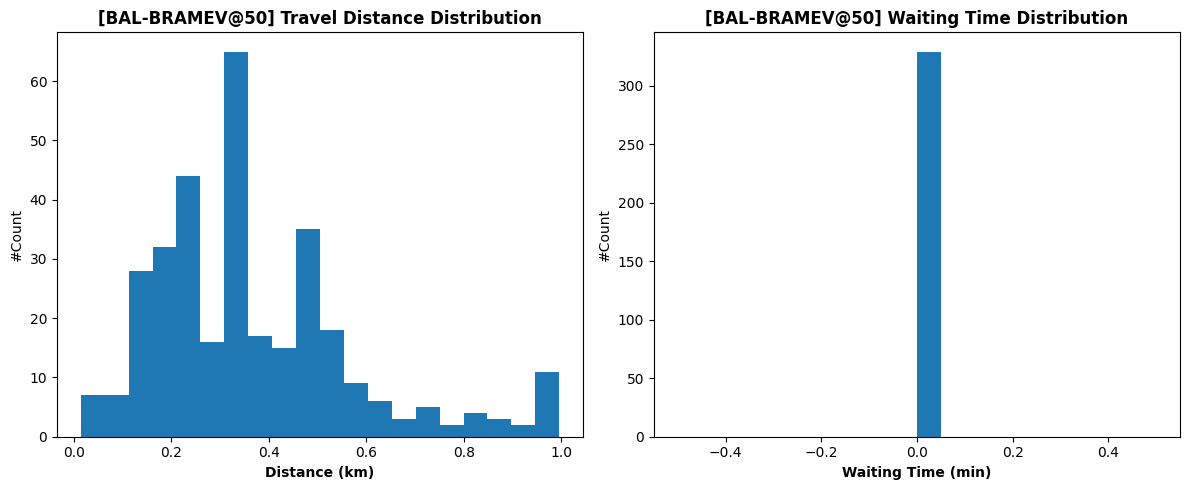

In [34]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

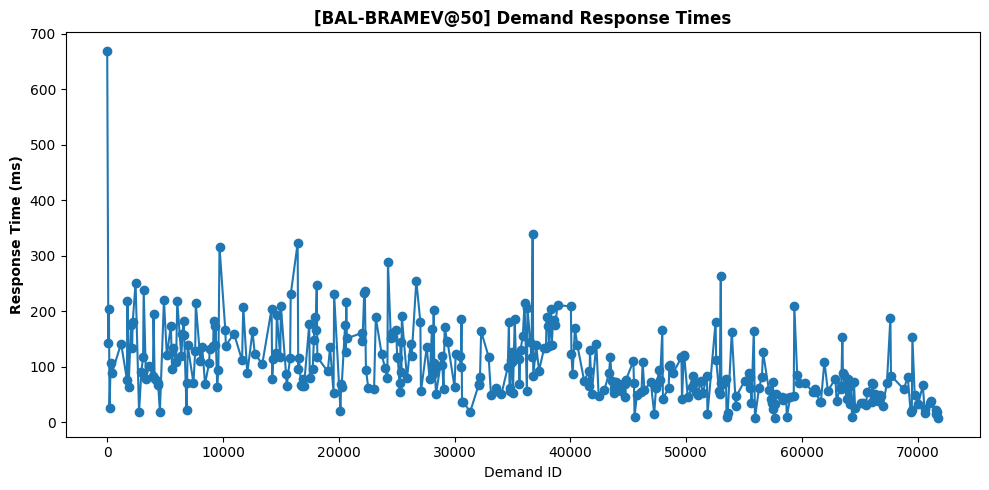

In [35]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

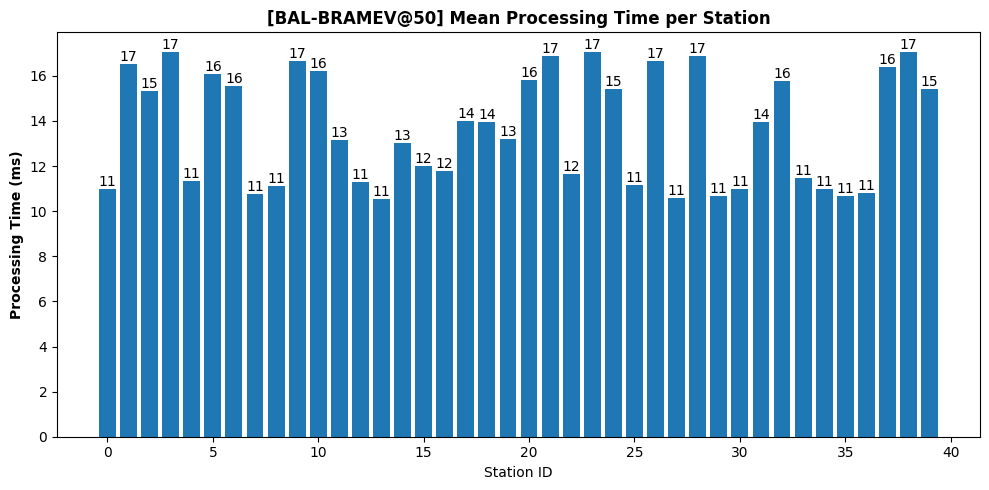

In [36]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

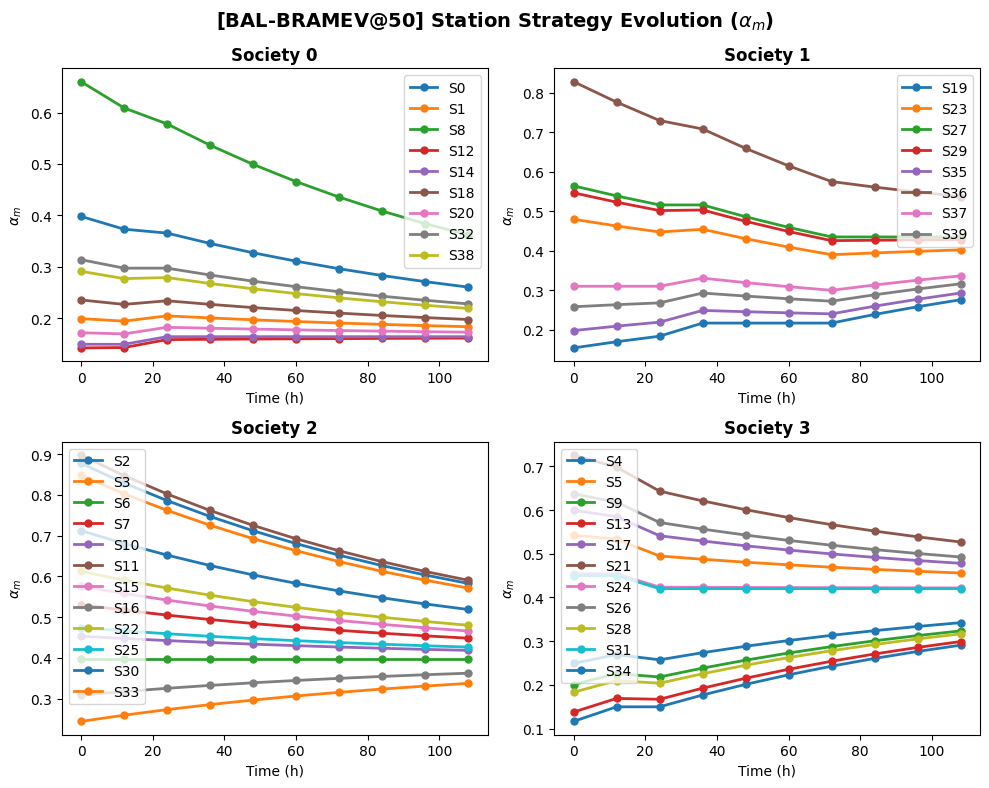

In [37]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [38]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

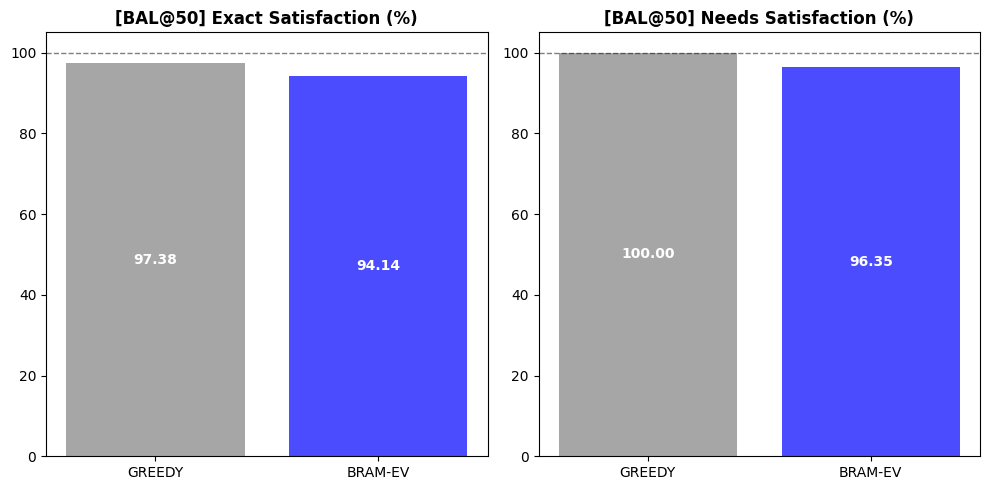

In [39]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

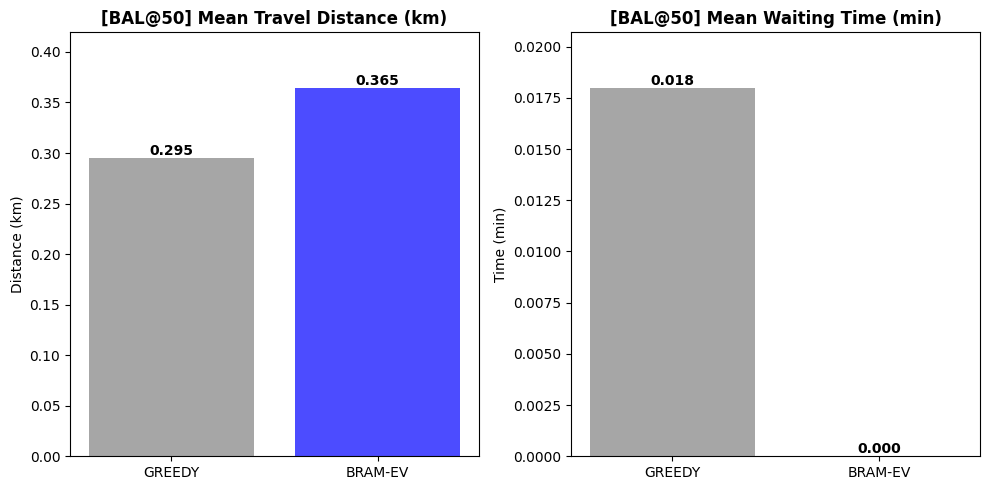

In [40]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

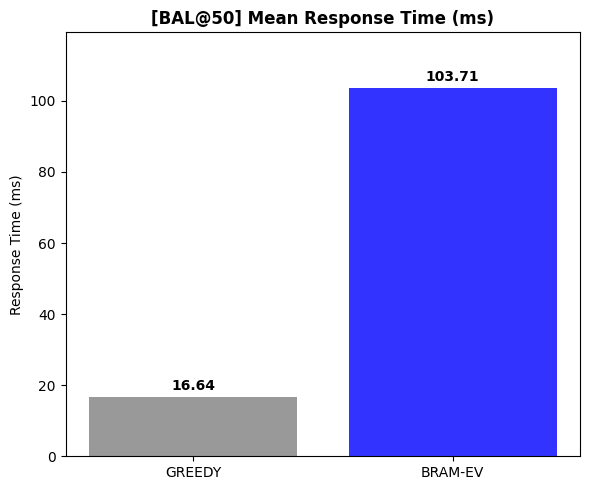

In [41]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [42]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [43]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/greedy/100cars


##### *Initialisation*

In [44]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [45]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:32:34.867 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-30 16:32:34.992 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-30 16:32:35.161 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-30 16:32:35.296 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-30 16:32:35.401 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-30 16:32:35.545 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-30 16:32:35.769 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-30 16:32:35.913 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-30 16:32:36.026 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-30 16:32:36.165 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-30 16:32:36.342 | IN

##### *Metrics*

In [46]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 37.31 kWh
  Station 1: 2.98 kWh
  Station 2: 3.71 kWh
  Station 3: 142.37 kWh
  Station 4: 1.83 kWh
  Station 5: 180.12 kWh
  Station 6: 1.50 kWh
  Station 7: 3.17 kWh
  Station 8: 2.43 kWh
  Station 9: 23.75 kWh
  Station 10: 4.91 kWh
  Station 11: 35.25 kWh
  Station 12: 32.20 kWh
  Station 13: 43.52 kWh
  Station 14: 2.53 kWh
  Station 15: 0.00 kWh
  Station 16: 1.50 kWh
  Station 17: 149.53 kWh
  Station 18: 5.97 kWh
  Station 19: 5.35 kWh
  Station 20: 46.03 kWh
  Station 21: 33.16 kWh
  Station 22: 13.75 kWh
  Station 23: 5.43 kWh
  Station 24: 25.57 kWh
  Station 25: 14.59 kWh
  Station 26: 0.00 kWh
  Station 27: 28.98 kWh
  Station 28: 0.00 kWh
  Station 29: 6.03 kWh
  Station 30: 44.47 kWh
  Station 31: 50.22 kWh
  Station 32: 3.80 kWh
  Station 33: 0.00 kWh
  Station 34: 1.81 kWh
  Station 35: 0.00 kWh
  Station 36: 137.70 kWh
  Station 37: 8.68 kWh
  Station 38: 1.80 kWh
  Station 39: 9.42 kWh

--- U

In [47]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

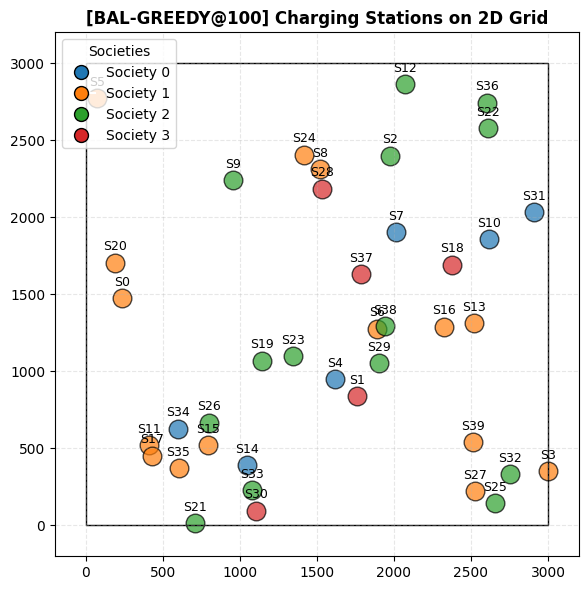

In [48]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

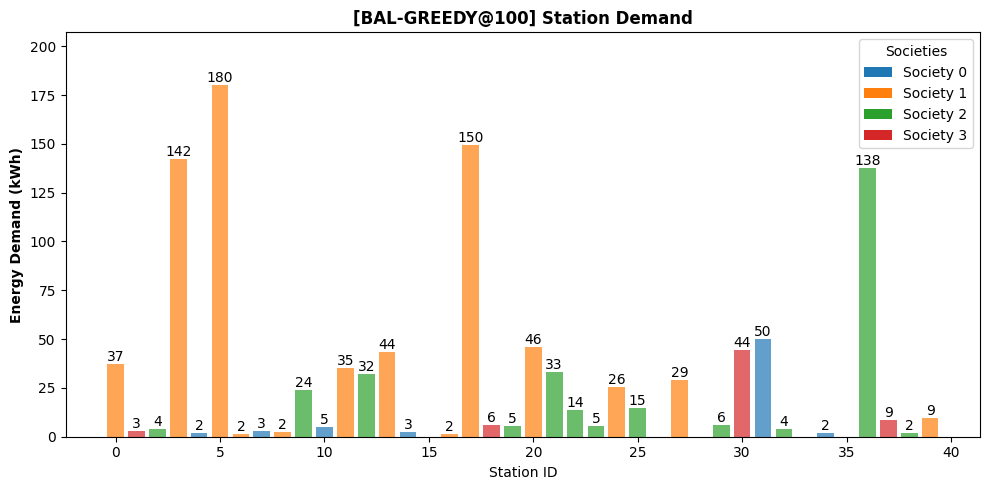

In [49]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

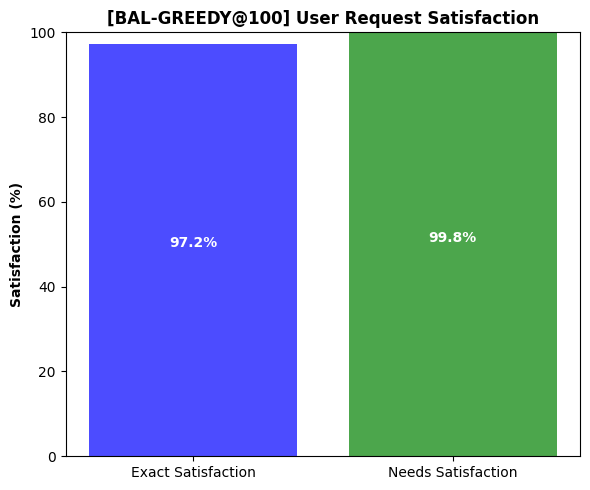

In [50]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

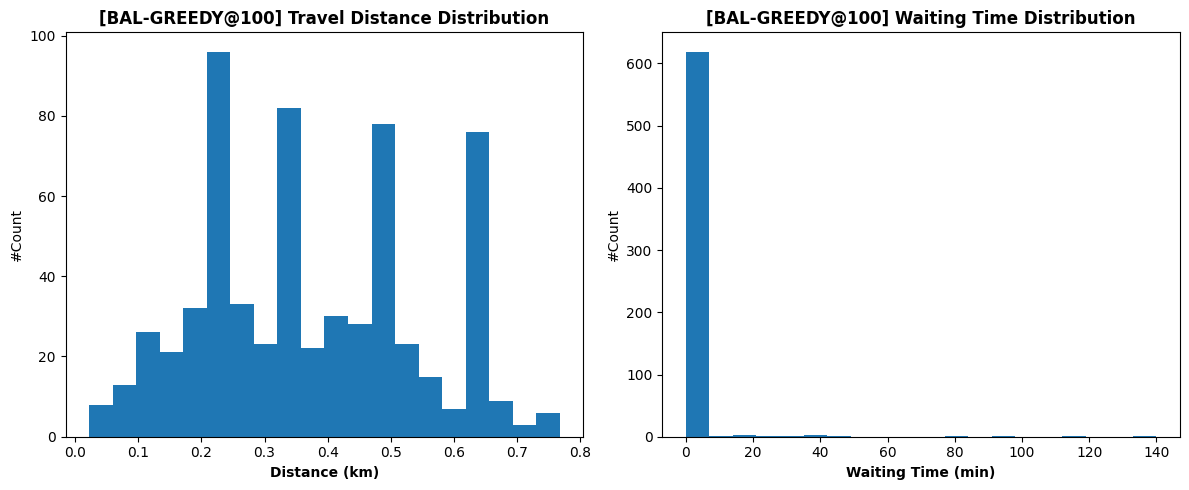

In [51]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

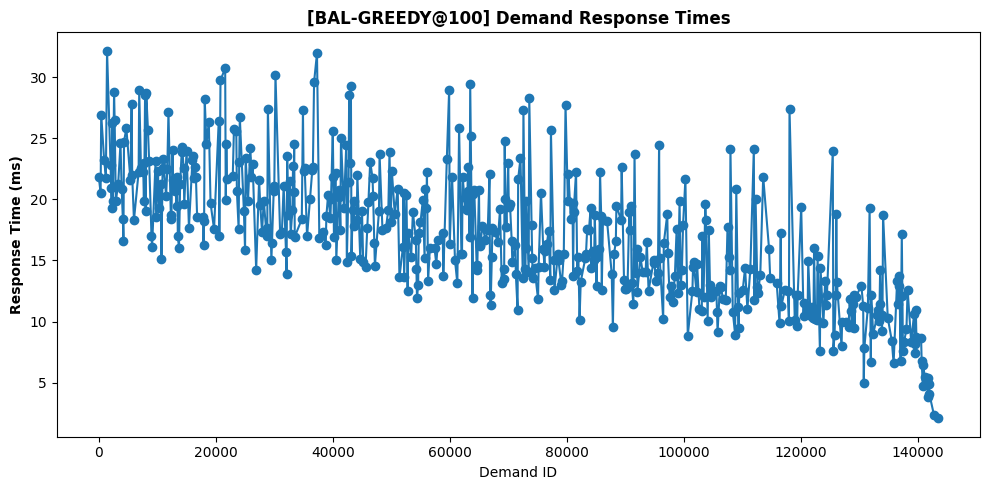

In [52]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

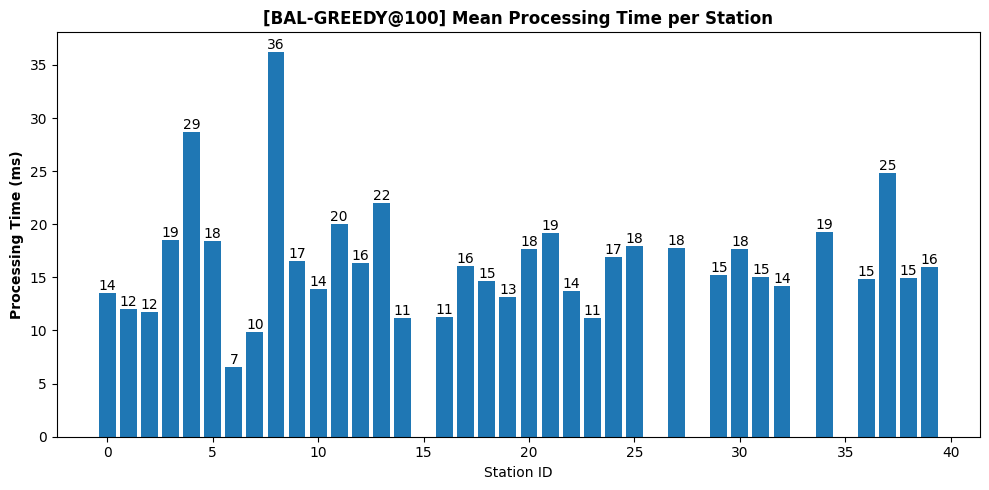

In [53]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [54]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/bramev/100cars


##### *Initialisation*

In [55]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [56]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:32:49.586 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-30 16:32:50.680 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-30 16:32:52.055 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-30 16:32:53.081 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-30 16:32:54.198 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-30 16:32:54.712 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-30 16:32:55.423 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-30 16:32:56.145 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-30 16:32:56.595 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-30 16:32:57.976 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-30 16:32:59.005 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [57]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 24.84 kWh
  Station 1: 6.03 kWh
  Station 2: 3.75 kWh
  Station 3: 24.41 kWh
  Station 4: 38.72 kWh
  Station 5: 3.15 kWh
  Station 6: 1.42 kWh
  Station 7: 7.23 kWh
  Station 8: 127.61 kWh
  Station 9: 40.11 kWh
  Station 10: 5.70 kWh
  Station 11: 11.10 kWh
  Station 12: 70.72 kWh
  Station 13: 125.32 kWh
  Station 14: 0.00 kWh
  Station 15: 17.16 kWh
  Station 16: 5.20 kWh
  Station 17: 11.51 kWh
  Station 18: 157.11 kWh
  Station 19: 62.61 kWh
  Station 20: 3.40 kWh
  Station 21: 22.36 kWh
  Station 22: 13.32 kWh
  Station 23: 2.73 kWh
  Station 24: 2.00 kWh
  Station 25: 2.81 kWh
  Station 26: 32.38 kWh
  Station 27: 7.70 kWh
  Station 28: 24.01 kWh
  Station 29: 18.84 kWh
  Station 30: 2.10 kWh
  Station 31: 135.88 kWh
  Station 32: 5.04 kWh
  Station 33: 27.93 kWh
  Station 34: 0.00 kWh
  Station 35: 24.92 kWh
  Station 36: 6.93 kWh
  Station 37: 2.07 kWh
  Station 38: 29.23 kWh
  Station 39: 11.50 kWh



In [58]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

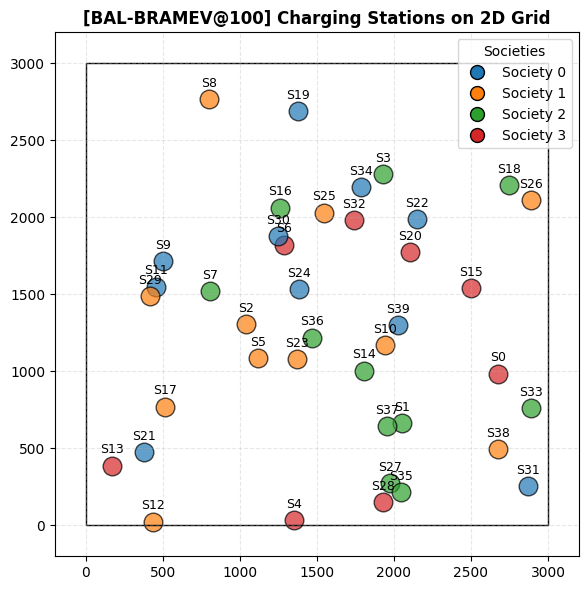

In [59]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

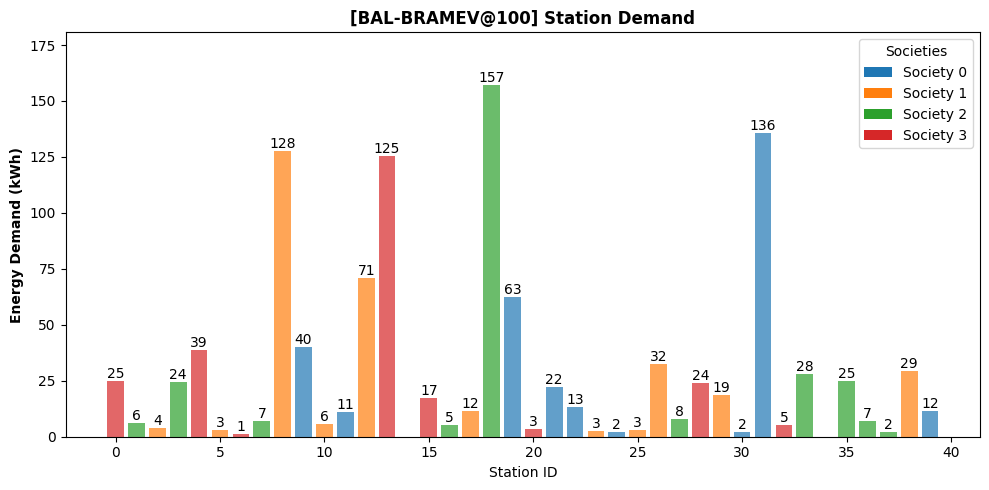

In [60]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

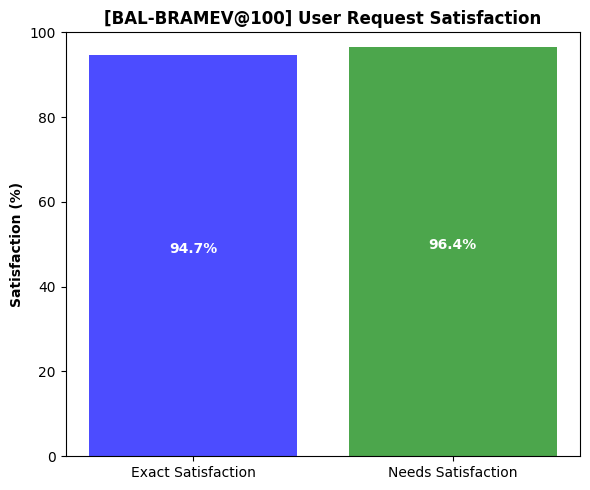

In [61]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

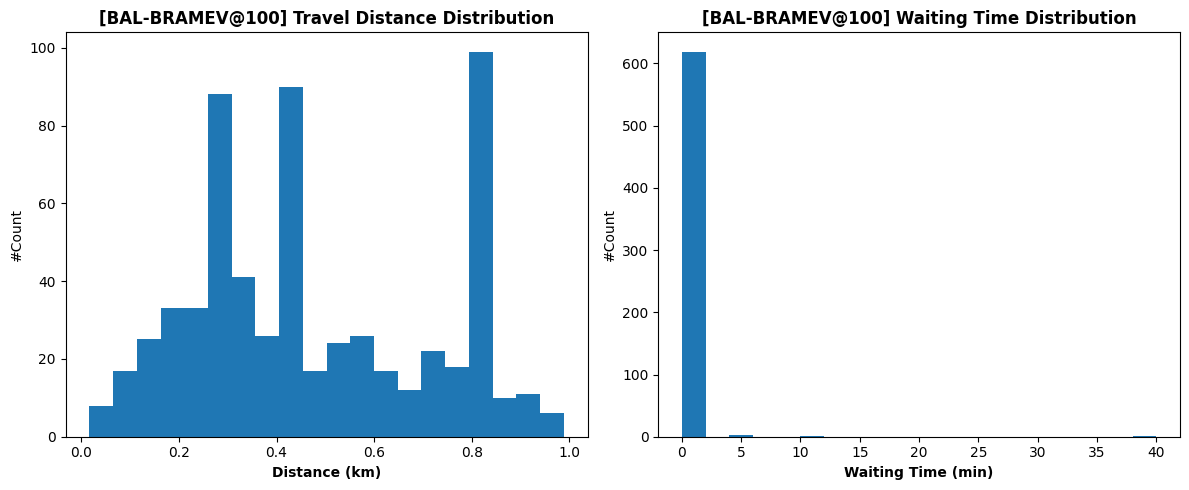

In [62]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

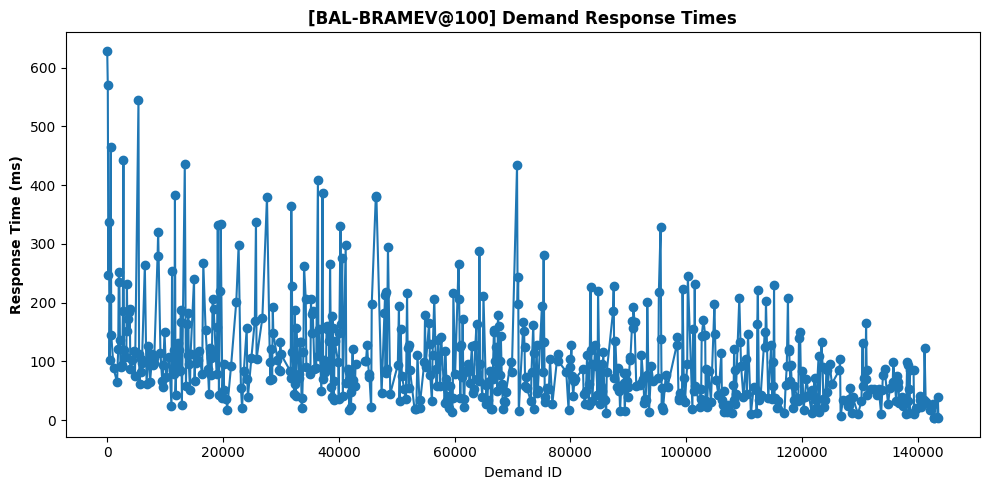

In [63]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

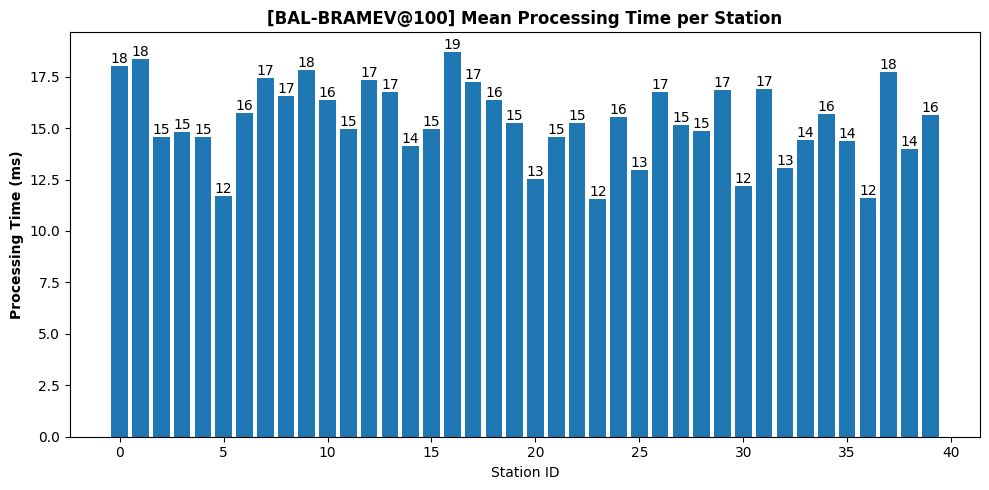

In [64]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

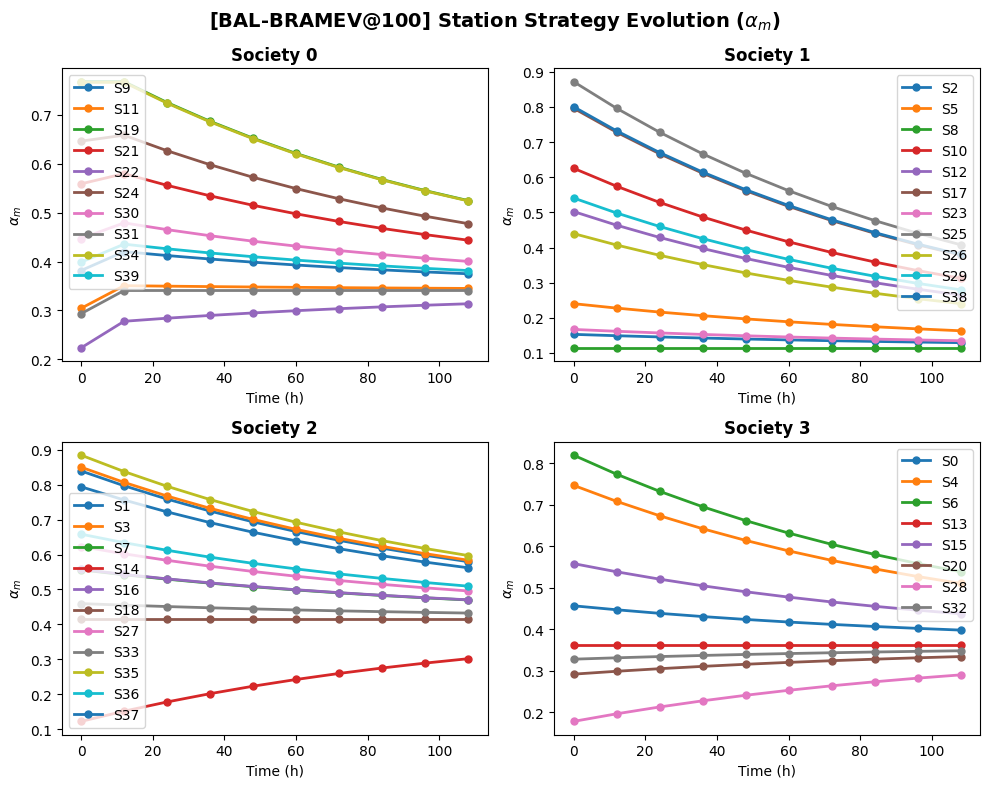

In [65]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [66]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

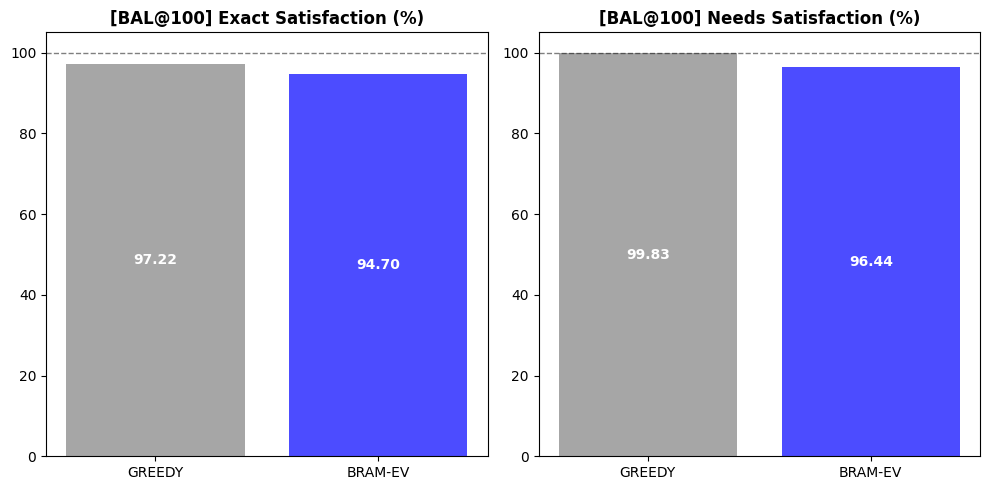

In [67]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

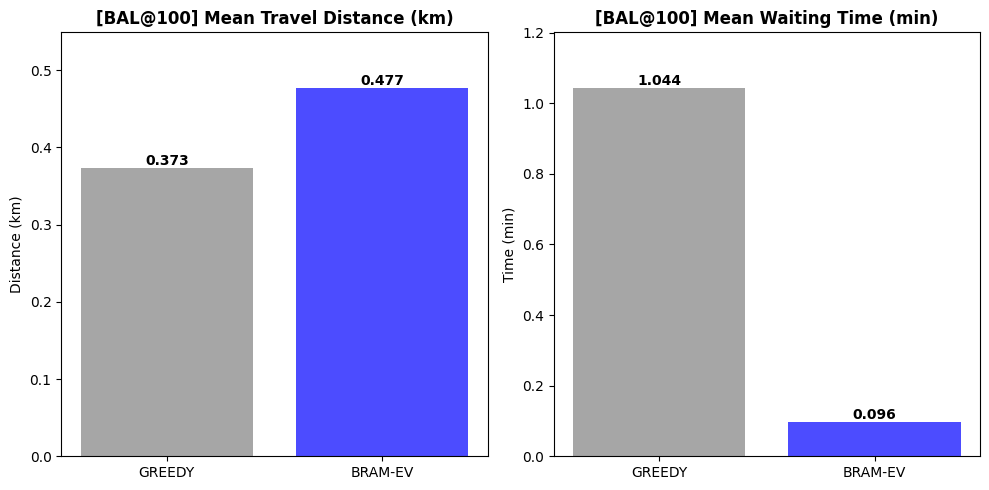

In [68]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

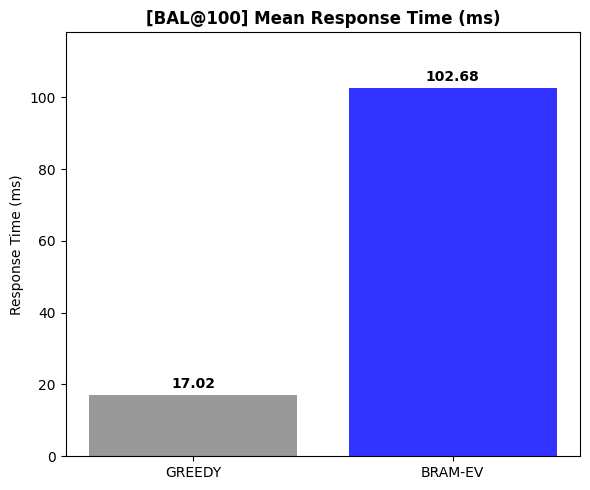

In [69]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [70]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [71]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/greedy/150cars


##### *Initialisation*

In [72]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [73]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:33:54.379 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-30 16:33:54.518 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-30 16:33:54.741 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-30 16:33:54.897 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-30 16:33:55.052 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-30 16:33:55.345 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-30 16:33:55.497 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-30 16:33:55.749 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-30 16:33:55.891 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-30 16:33:56.051 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-30 16:33:56.360 | IN

##### *Metrics*

In [74]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 16.88 kWh
  Station 1: 1.52 kWh
  Station 2: 2.50 kWh
  Station 3: 19.42 kWh
  Station 4: 199.42 kWh
  Station 5: 7.53 kWh
  Station 6: 7.84 kWh
  Station 7: 60.94 kWh
  Station 8: 0.00 kWh
  Station 9: 44.27 kWh
  Station 10: 53.26 kWh
  Station 11: 60.49 kWh
  Station 12: 49.23 kWh
  Station 13: 0.00 kWh
  Station 14: 0.00 kWh
  Station 15: 3.30 kWh
  Station 16: 3.75 kWh
  Station 17: 34.77 kWh
  Station 18: 41.41 kWh
  Station 19: 12.11 kWh
  Station 20: 10.02 kWh
  Station 21: 4.26 kWh
  Station 22: 235.69 kWh
  Station 23: 15.32 kWh
  Station 24: 7.05 kWh
  Station 25: 0.00 kWh
  Station 26: 6.70 kWh
  Station 27: 235.74 kWh
  Station 28: 198.31 kWh
  Station 29: 34.92 kWh
  Station 30: 54.24 kWh
  Station 31: 11.93 kWh
  Station 32: 2.00 kWh
  Station 33: 66.72 kWh
  Station 34: 8.35 kWh
  Station 35: 46.44 kWh
  Station 36: 4.69 kWh
  Station 37: 50.02 kWh
  Station 38: 6.44 kWh
  Station 39: 9.32 kWh



In [75]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

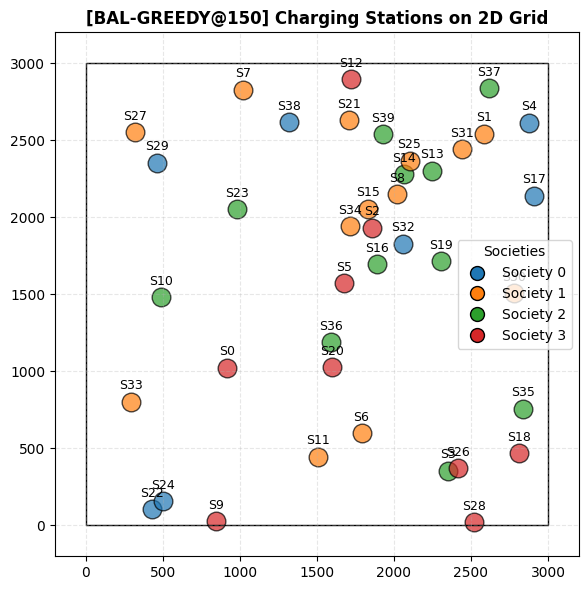

In [76]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

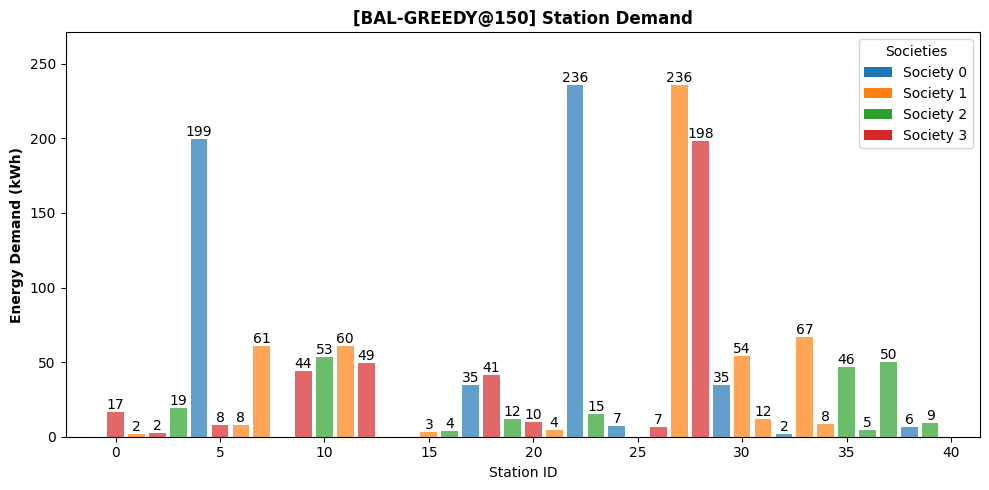

In [77]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

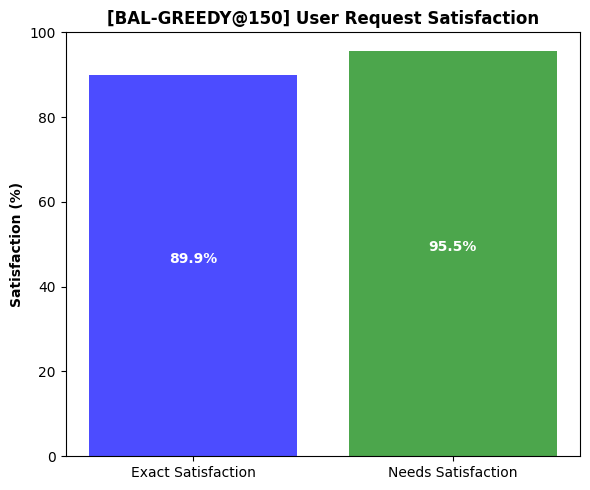

In [78]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

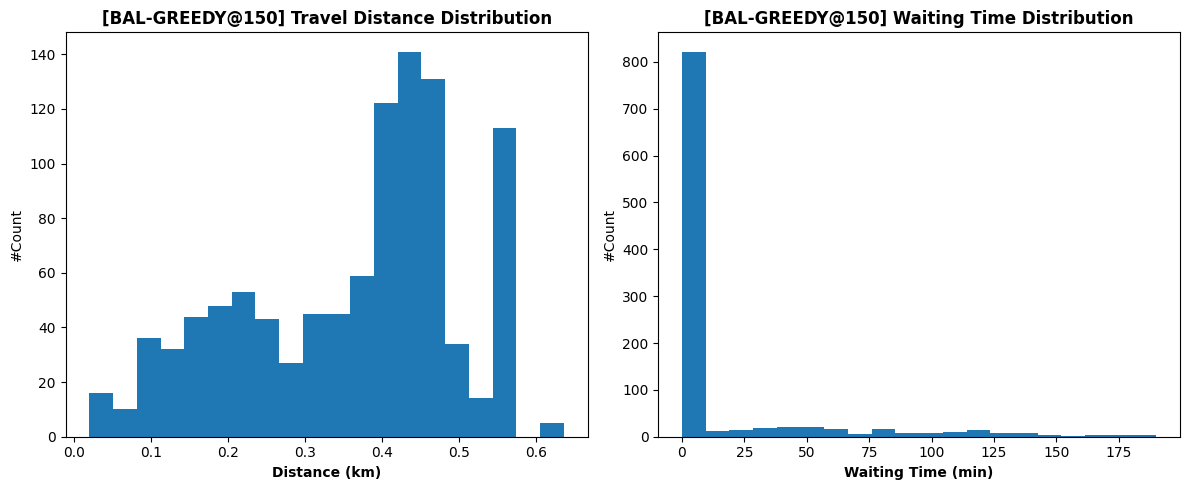

In [79]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

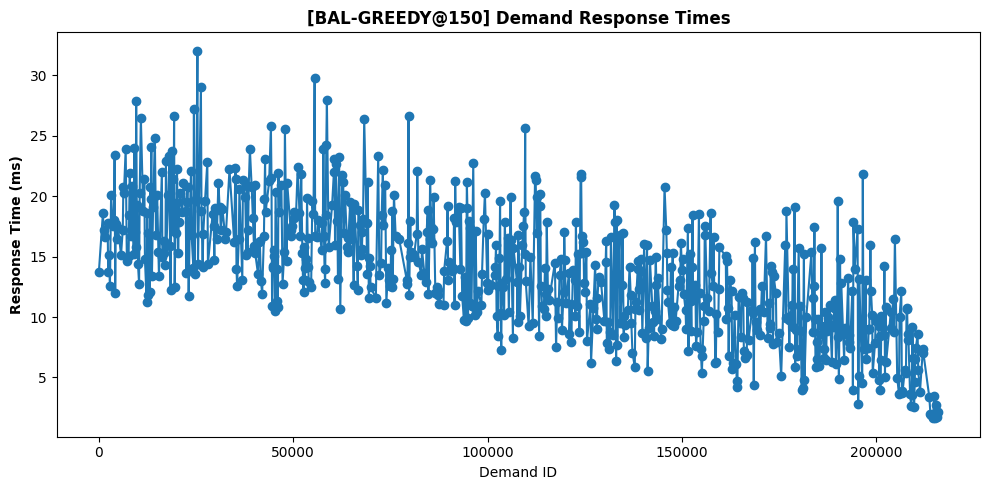

In [80]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

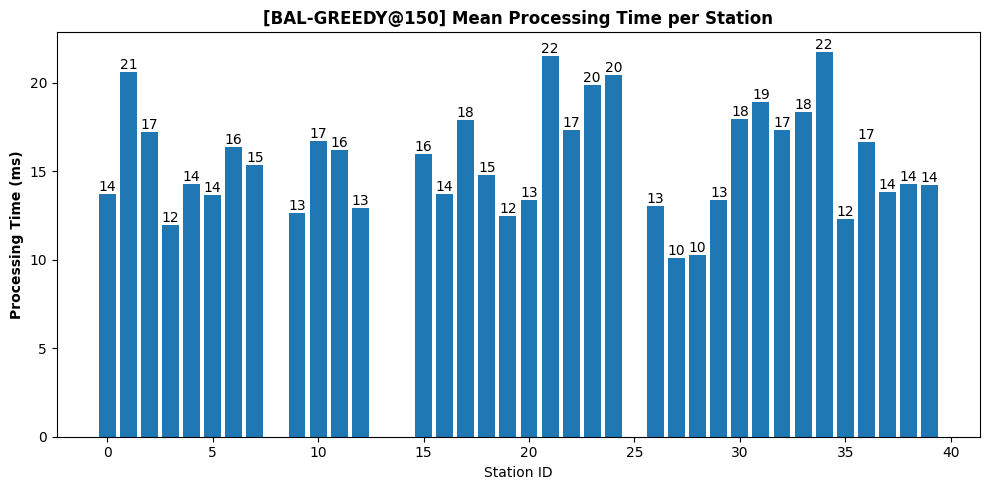

In [81]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [82]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/bramev/150cars


##### *Initialisation*

In [83]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [84]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:34:13.270 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-30 16:34:14.350 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-30 16:34:15.303 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-30 16:34:17.402 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-30 16:34:19.233 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-30 16:34:21.774 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-30 16:34:23.232 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-30 16:34:25.112 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-30 16:34:28.045 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-30 16:34:31.208 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-30 16:34:34.076 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [85]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 64.81 kWh
  Station 1: 9.62 kWh
  Station 2: 7.53 kWh
  Station 3: 30.00 kWh
  Station 4: 10.72 kWh
  Station 5: 5.72 kWh
  Station 6: 35.50 kWh
  Station 7: 5.28 kWh
  Station 8: 6.37 kWh
  Station 9: 12.57 kWh
  Station 10: 17.07 kWh
  Station 11: 12.22 kWh
  Station 12: 93.35 kWh
  Station 13: 103.08 kWh
  Station 14: 27.73 kWh
  Station 15: 18.54 kWh
  Station 16: 14.71 kWh
  Station 17: 16.37 kWh
  Station 18: 104.60 kWh
  Station 19: 133.63 kWh
  Station 20: 61.00 kWh
  Station 21: 121.03 kWh
  Station 22: 131.46 kWh
  Station 23: 12.13 kWh
  Station 24: 34.07 kWh
  Station 25: 47.62 kWh
  Station 26: 64.85 kWh
  Station 27: 1.43 kWh
  Station 28: 19.72 kWh
  Station 29: 41.16 kWh
  Station 30: 49.14 kWh
  Station 31: 73.36 kWh
  Station 32: 19.09 kWh
  Station 33: 40.47 kWh
  Station 34: 154.56 kWh
  Station 35: 7.25 kWh
  Station 36: 6.85 kWh
  Station 37: 4.53 kWh
  Station 38: 38.66 kWh
  Station 39: 

In [86]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

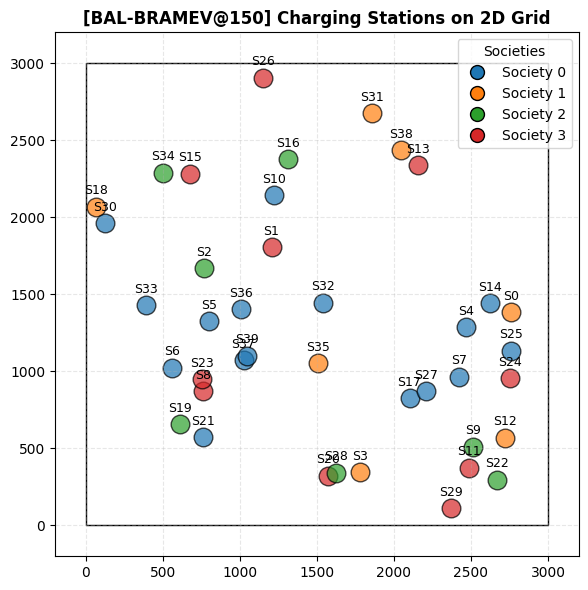

In [87]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

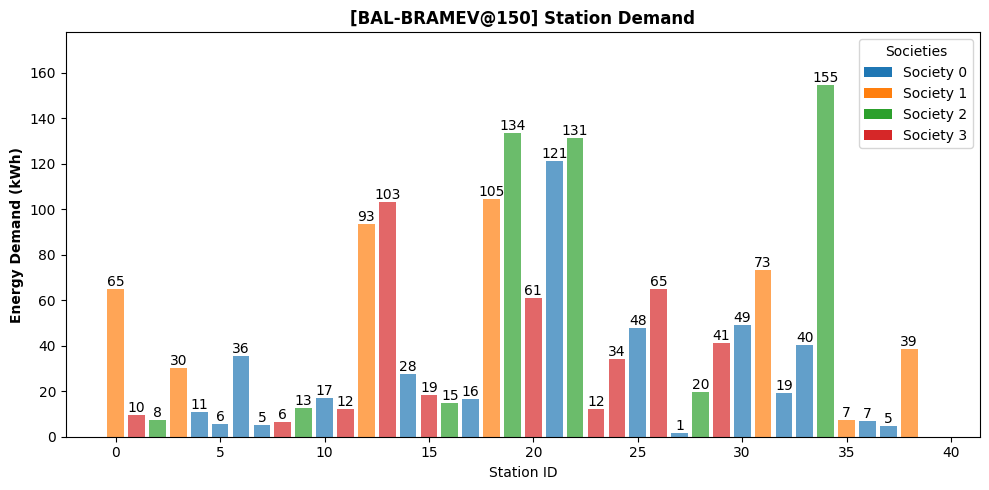

In [88]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

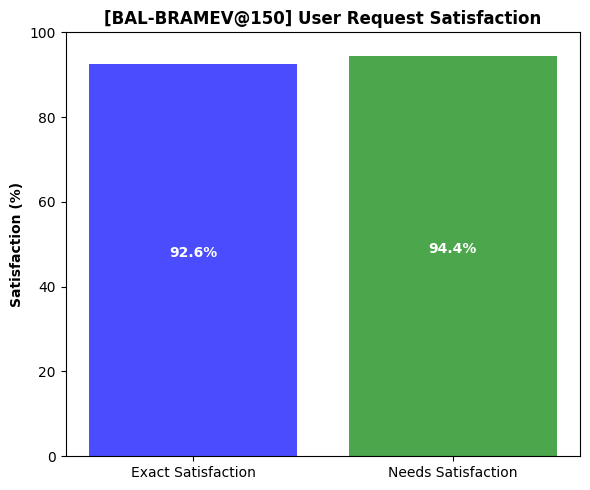

In [89]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

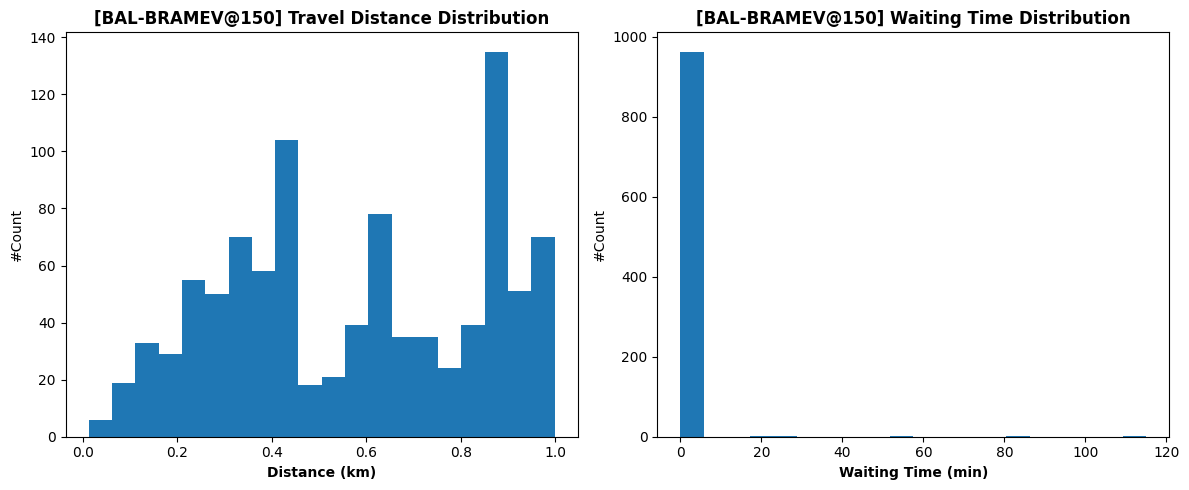

In [90]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

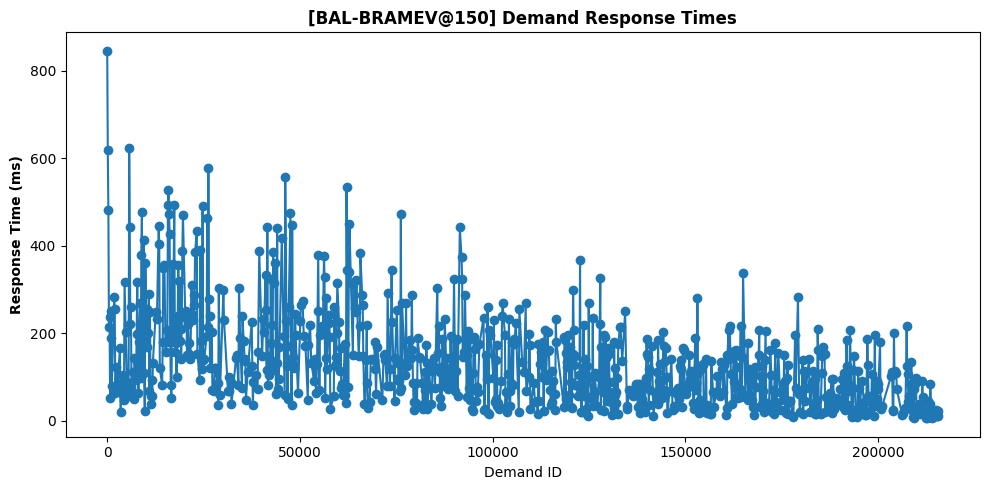

In [91]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

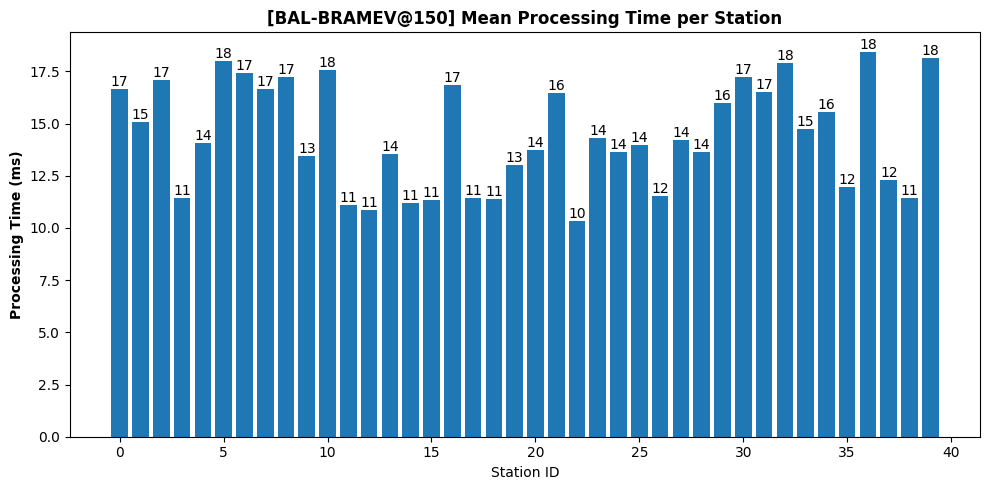

In [92]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

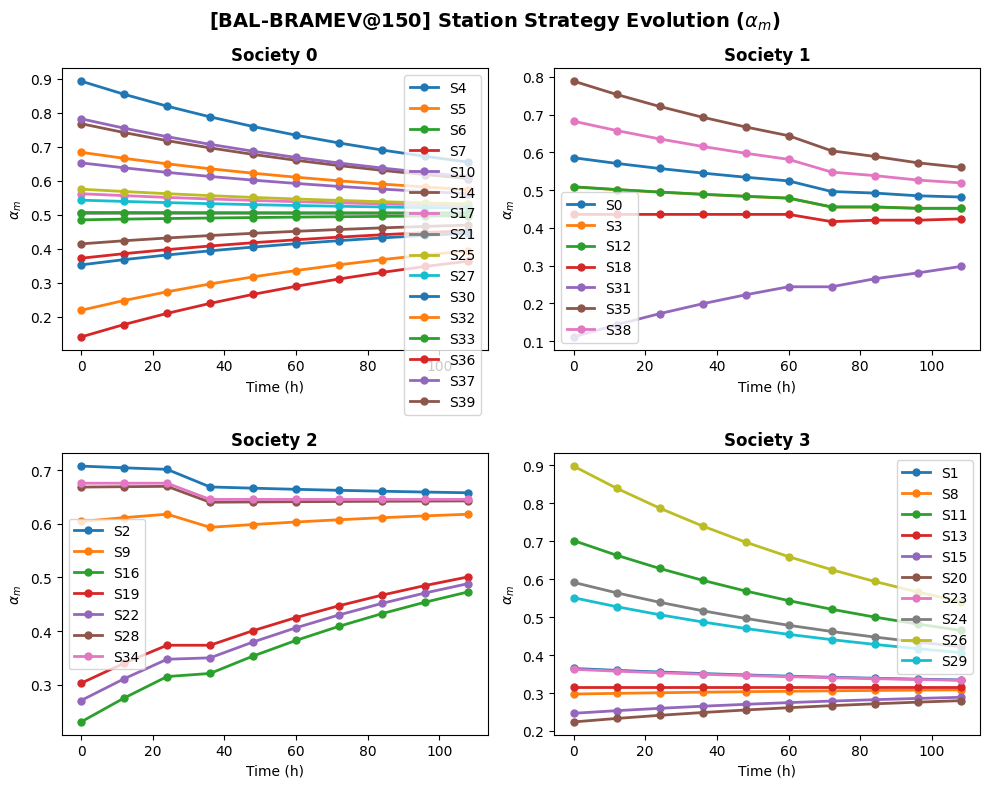

In [93]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [94]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

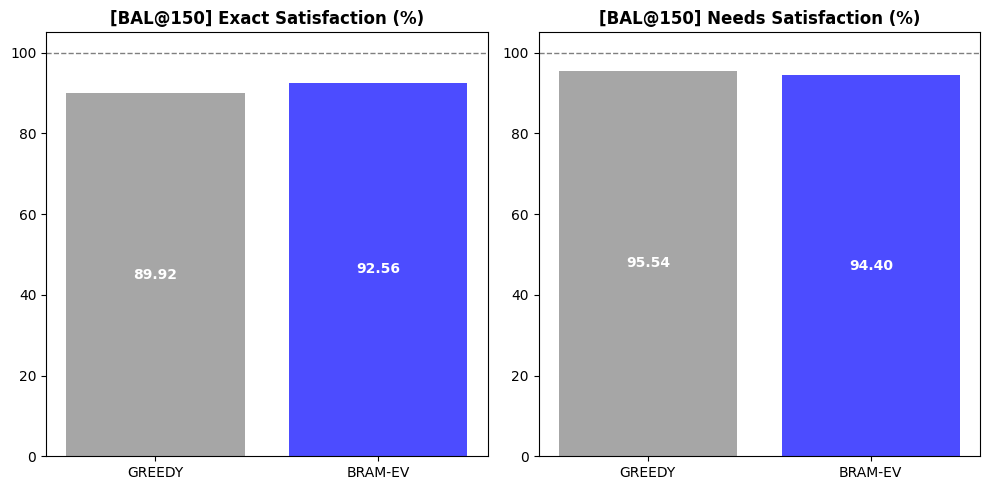

In [95]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

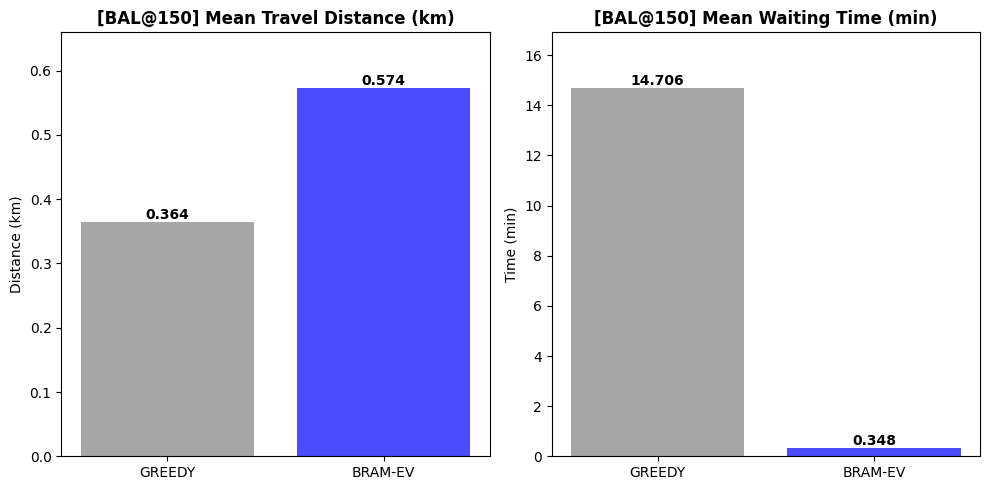

In [96]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

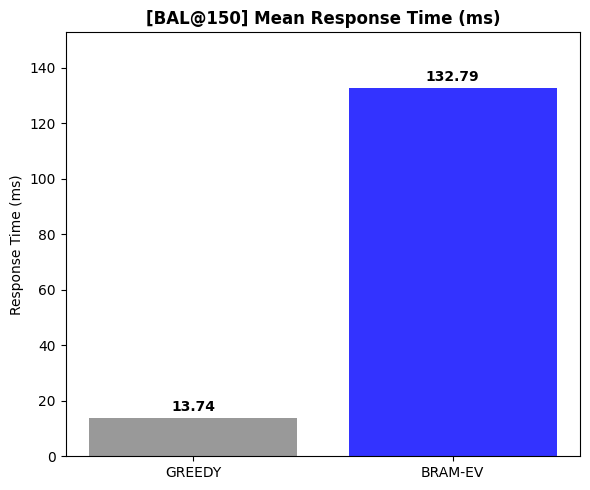

In [97]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [98]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [99]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/greedy/200cars


##### *Initialisation*

In [100]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [101]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:36:26.394 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-30 16:36:26.582 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-30 16:36:26.814 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-30 16:36:27.031 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-30 16:36:27.279 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-30 16:36:27.431 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-30 16:36:27.630 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-30 16:36:27.939 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-30 16:36:28.237 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-30 16:36:28.534 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-30 16:36:28.810 | IN

##### *Metrics*

In [102]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 39.05 kWh
  Station 1: 55.83 kWh
  Station 2: 28.44 kWh
  Station 3: 6.01 kWh
  Station 4: 5.90 kWh
  Station 5: 260.40 kWh
  Station 6: 3.77 kWh
  Station 7: 5.88 kWh
  Station 8: 13.74 kWh
  Station 9: 119.69 kWh
  Station 10: 64.24 kWh
  Station 11: 5.37 kWh
  Station 12: 15.54 kWh
  Station 13: 14.66 kWh
  Station 14: 32.14 kWh
  Station 15: 48.36 kWh
  Station 16: 70.86 kWh
  Station 17: 11.15 kWh
  Station 18: 0.00 kWh
  Station 19: 49.23 kWh
  Station 20: 40.85 kWh
  Station 21: 0.00 kWh
  Station 22: 13.17 kWh
  Station 23: 245.44 kWh
  Station 24: 37.01 kWh
  Station 25: 38.82 kWh
  Station 26: 15.62 kWh
  Station 27: 101.30 kWh
  Station 28: 69.96 kWh
  Station 29: 13.49 kWh
  Station 30: 5.84 kWh
  Station 31: 14.35 kWh
  Station 32: 9.92 kWh
  Station 33: 53.62 kWh
  Station 34: 30.73 kWh
  Station 35: 252.78 kWh
  Station 36: 289.35 kWh
  Station 37: 3.49 kWh
  Station 38: 17.18 kWh
  Station 39: 4

In [103]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

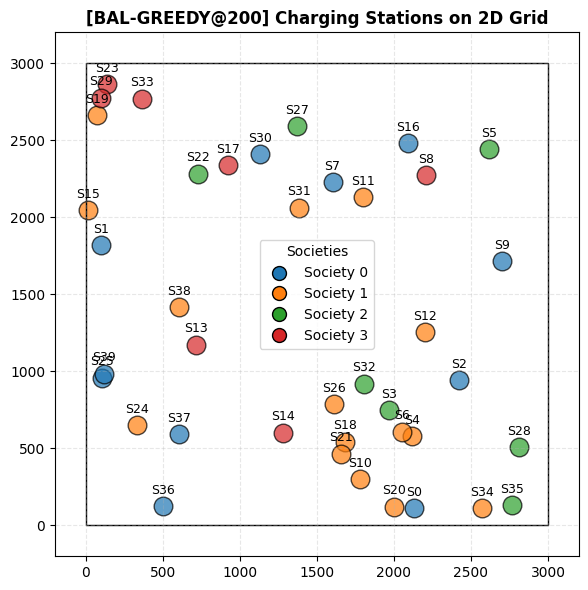

In [104]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

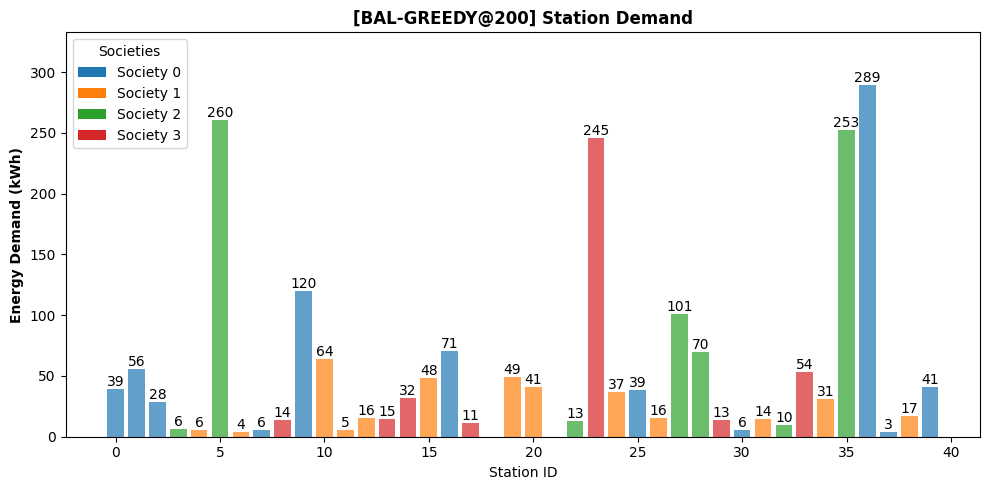

In [105]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

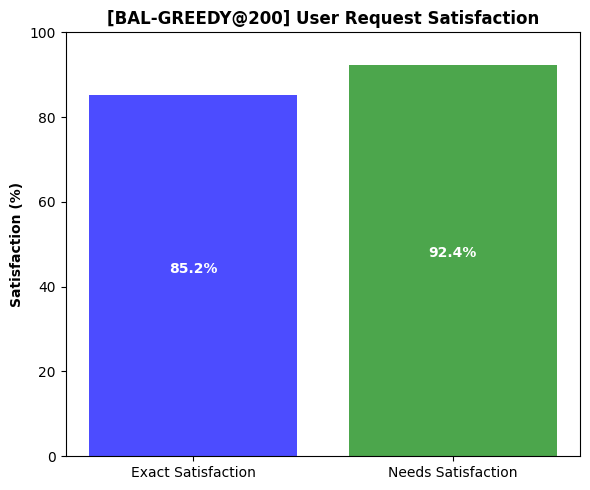

In [106]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

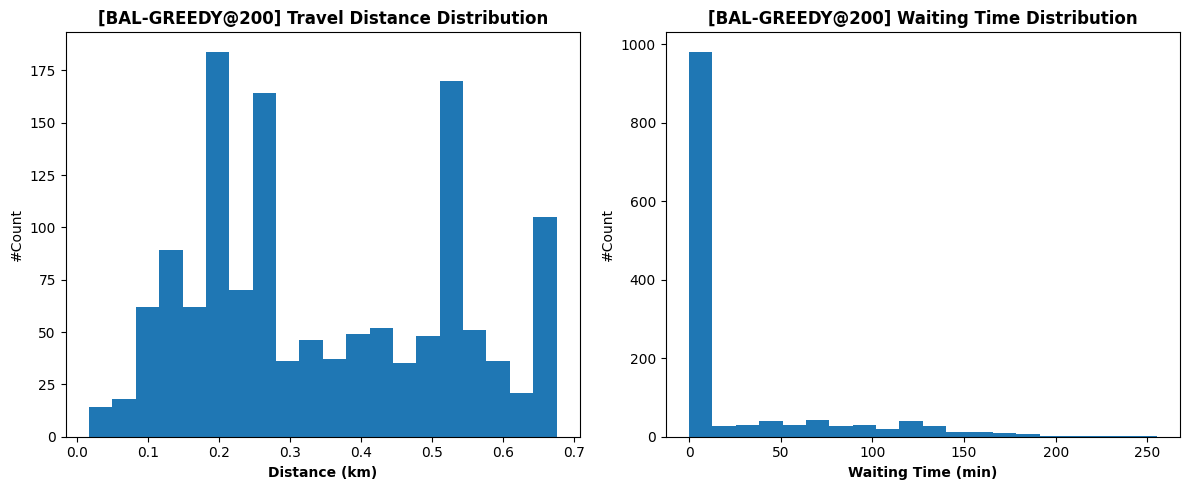

In [107]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

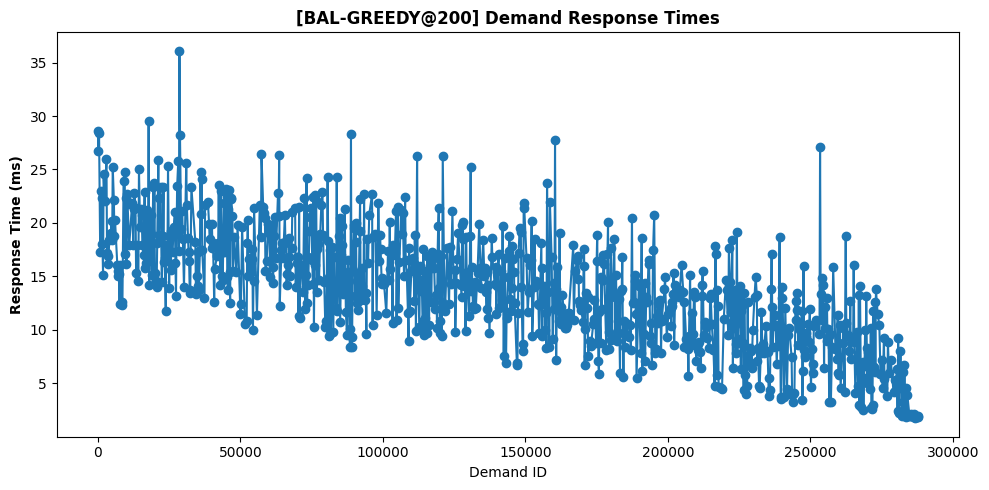

In [108]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

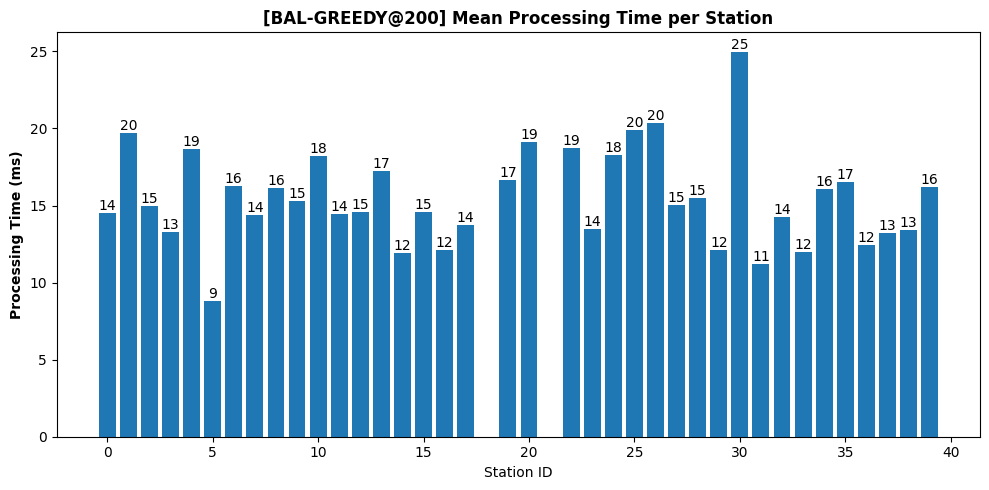

In [109]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [110]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/bramev/200cars


##### *Initialisation*

In [111]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [112]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:36:53.330 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-30 16:36:55.017 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-30 16:36:56.404 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-30 16:36:58.230 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-30 16:37:00.452 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-30 16:37:02.979 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-30 16:37:04.627 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-30 16:37:06.812 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-30 16:37:09.138 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-30 16:37:10.661 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-30 16:37:12.926 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [113]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 45.50 kWh
  Station 1: 22.48 kWh
  Station 2: 46.53 kWh
  Station 3: 9.32 kWh
  Station 4: 37.36 kWh
  Station 5: 72.61 kWh
  Station 6: 173.88 kWh
  Station 7: 86.53 kWh
  Station 8: 76.22 kWh
  Station 9: 3.35 kWh
  Station 10: 19.89 kWh
  Station 11: 14.26 kWh
  Station 12: 4.80 kWh
  Station 13: 23.82 kWh
  Station 14: 12.45 kWh
  Station 15: 93.80 kWh
  Station 16: 9.42 kWh
  Station 17: 30.25 kWh
  Station 18: 107.28 kWh
  Station 19: 22.37 kWh
  Station 20: 198.67 kWh
  Station 21: 8.34 kWh
  Station 22: 13.38 kWh
  Station 23: 16.45 kWh
  Station 24: 154.78 kWh
  Station 25: 129.64 kWh
  Station 26: 117.40 kWh
  Station 27: 50.78 kWh
  Station 28: 75.53 kWh
  Station 29: 10.54 kWh
  Station 30: 49.09 kWh
  Station 31: 11.74 kWh
  Station 32: 110.17 kWh
  Station 33: 167.53 kWh
  Station 34: 24.30 kWh
  Station 35: 51.89 kWh
  Station 36: 8.53 kWh
  Station 37: 11.34 kWh
  Station 38: 20.34 kWh
  Station

In [114]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

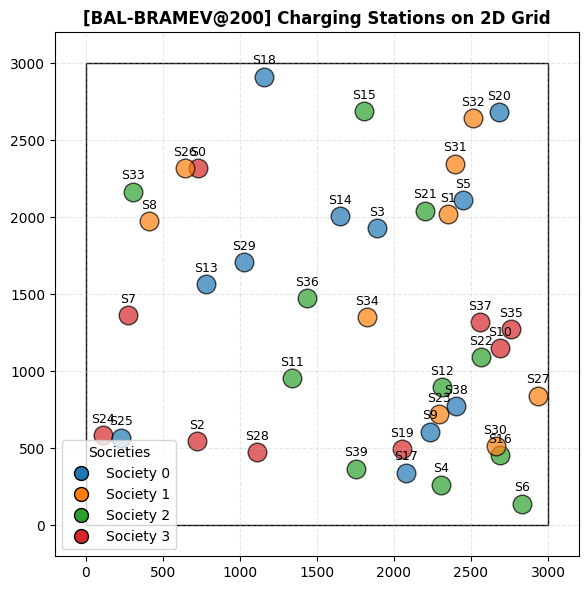

In [115]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

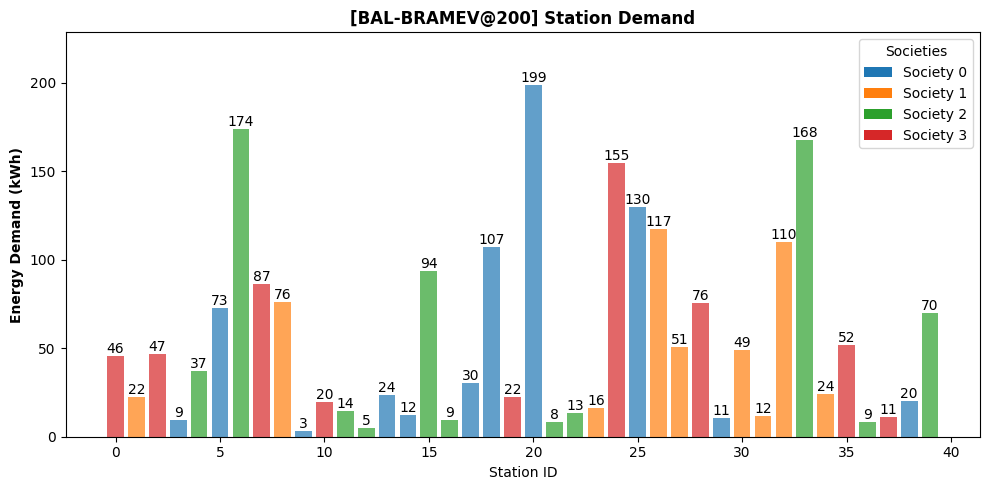

In [116]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

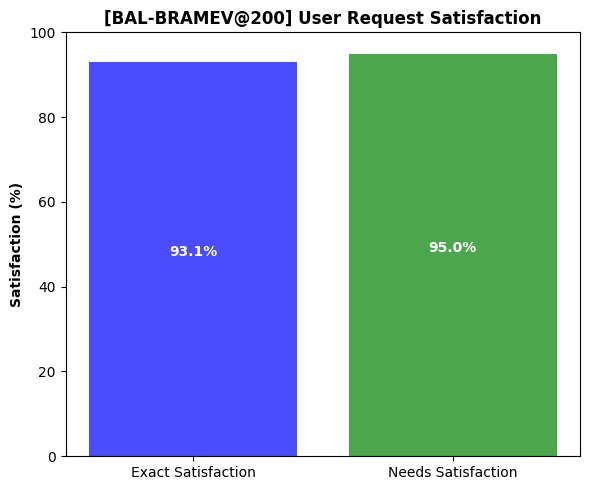

In [117]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

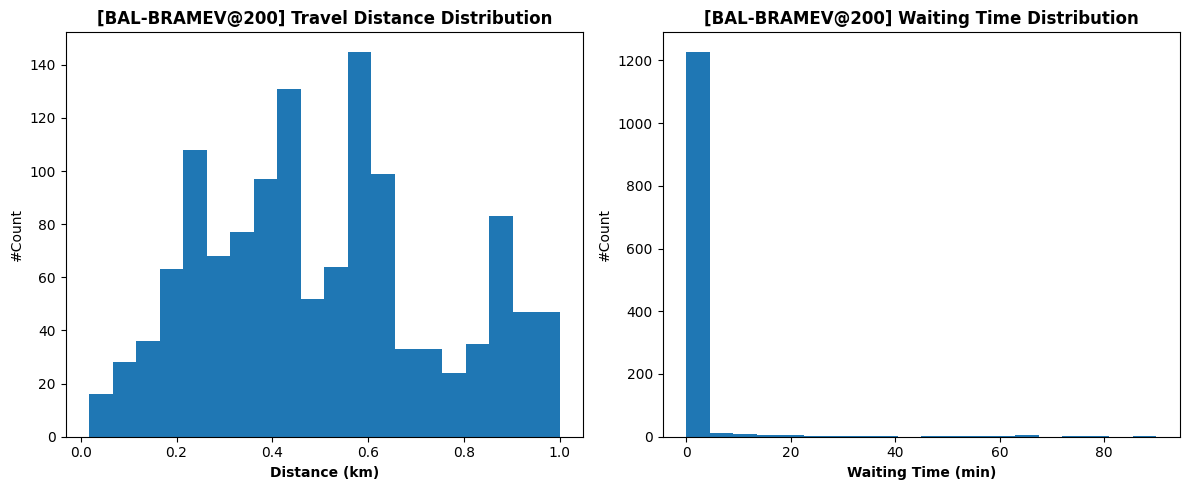

In [118]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

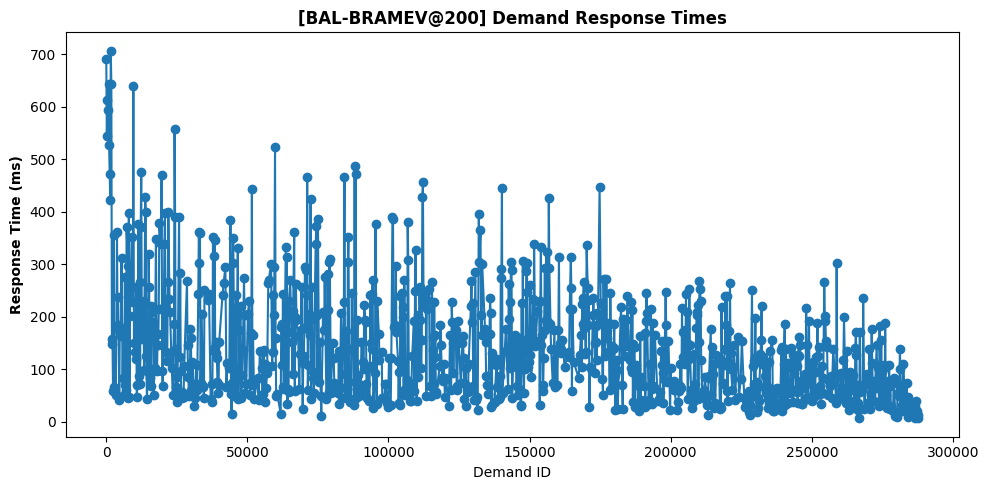

In [119]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

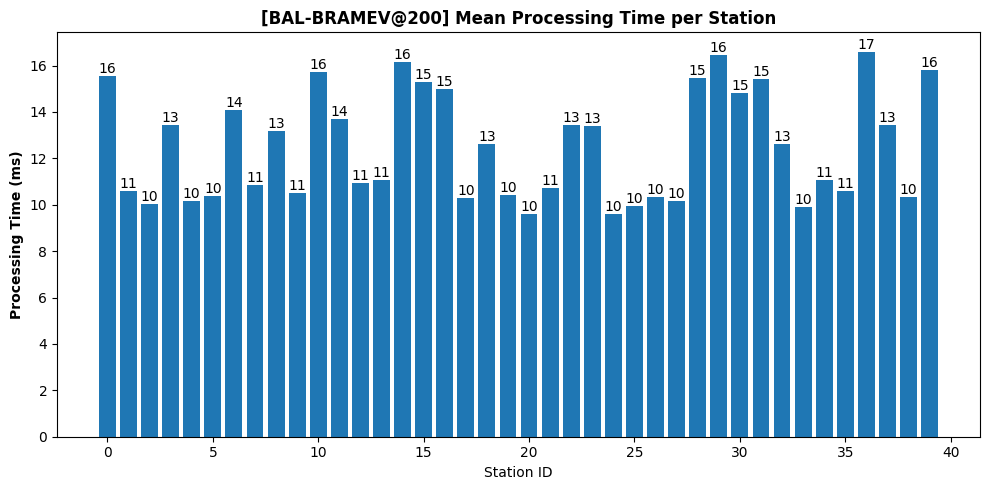

In [120]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

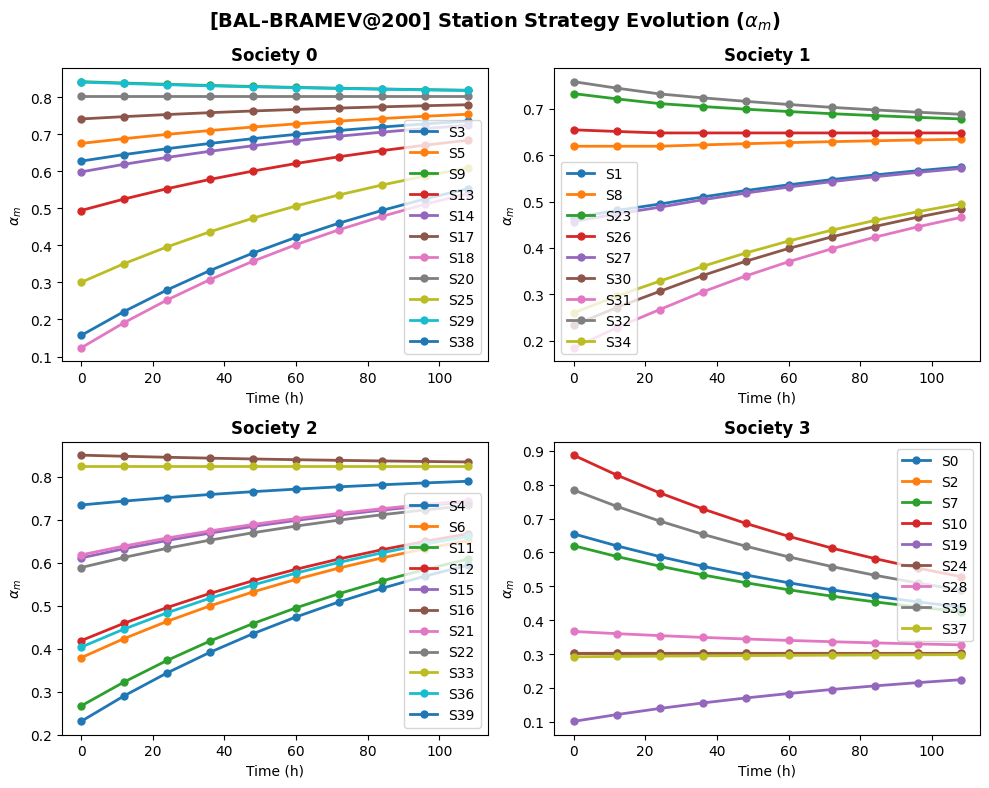

In [121]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [122]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

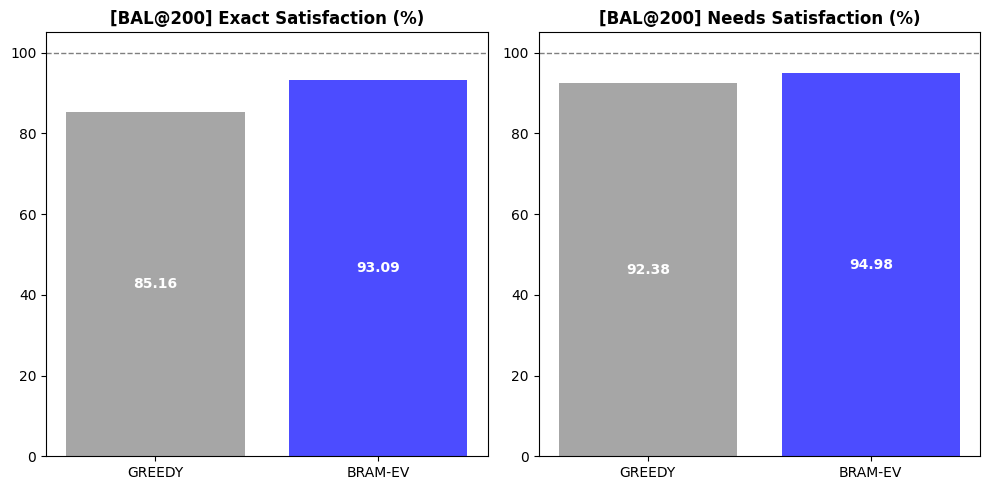

In [123]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

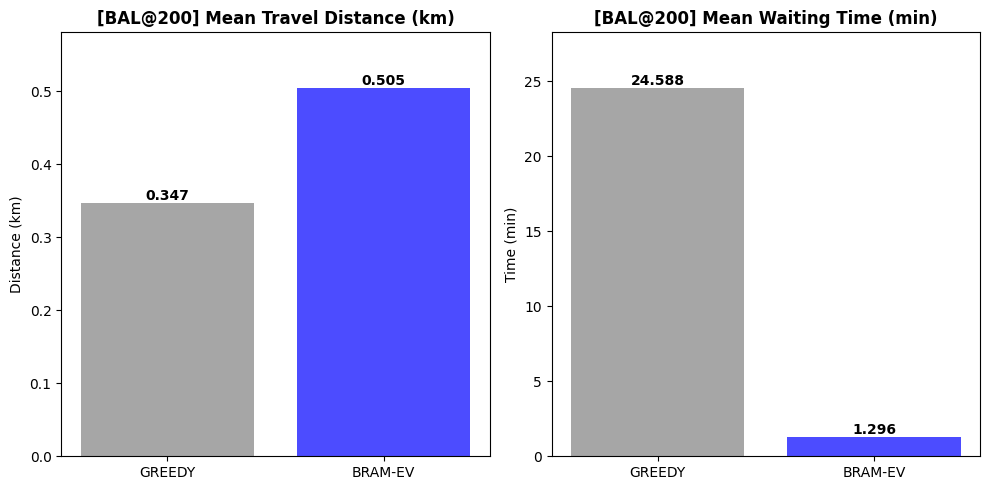

In [124]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

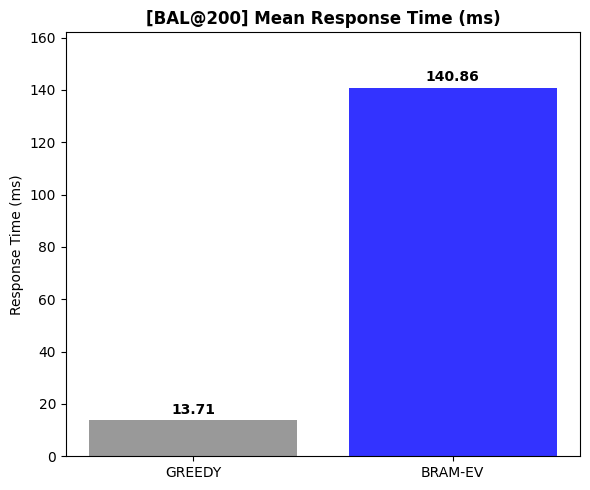

In [125]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [126]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [127]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/greedy/250cars


##### *Initialisation*

In [128]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [129]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:39:27.145 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-30 16:39:27.594 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-30 16:39:27.923 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-30 16:39:28.222 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-30 16:39:28.518 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-30 16:39:28.763 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-30 16:39:29.121 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-30 16:39:29.523 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-30 16:39:29.924 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-30 16:39:30.279 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-30 16:39:30.643 | IN

##### *Metrics*

In [130]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 32.36 kWh
  Station 1: 8.62 kWh
  Station 2: 322.58 kWh
  Station 3: 15.19 kWh
  Station 4: 137.33 kWh
  Station 5: 19.24 kWh
  Station 6: 1.46 kWh
  Station 7: 116.03 kWh
  Station 8: 5.70 kWh
  Station 9: 0.00 kWh
  Station 10: 20.88 kWh
  Station 11: 11.56 kWh
  Station 12: 36.85 kWh
  Station 13: 92.78 kWh
  Station 14: 0.00 kWh
  Station 15: 14.04 kWh
  Station 16: 10.46 kWh
  Station 17: 12.11 kWh
  Station 18: 54.27 kWh
  Station 19: 21.56 kWh
  Station 20: 1.60 kWh
  Station 21: 355.01 kWh
  Station 22: 53.42 kWh
  Station 23: 14.42 kWh
  Station 24: 61.09 kWh
  Station 25: 8.69 kWh
  Station 26: 5.12 kWh
  Station 27: 5.13 kWh
  Station 28: 311.51 kWh
  Station 29: 55.08 kWh
  Station 30: 82.76 kWh
  Station 31: 11.21 kWh
  Station 32: 140.77 kWh
  Station 33: 368.65 kWh
  Station 34: 22.40 kWh
  Station 35: 16.05 kWh
  Station 36: 1.52 kWh
  Station 37: 45.58 kWh
  Station 38: 51.38 kWh
  Station 39: 

In [131]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

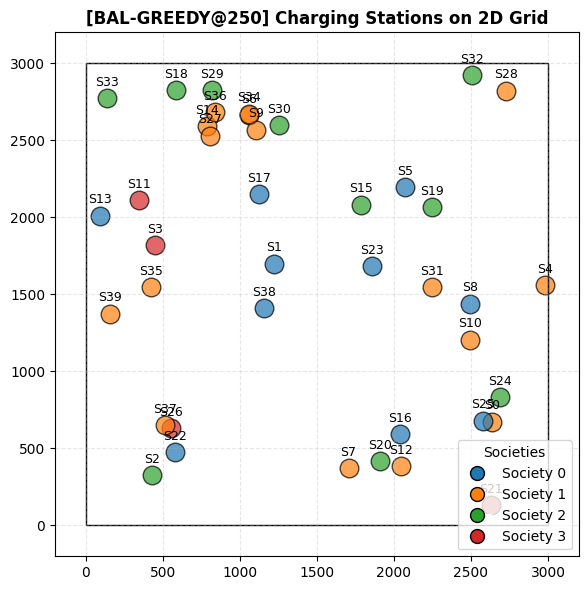

In [132]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

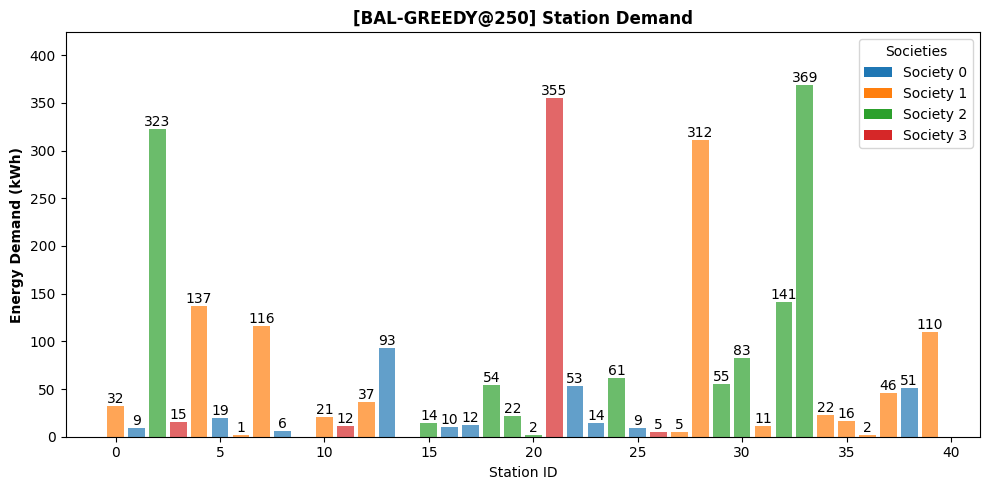

In [133]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

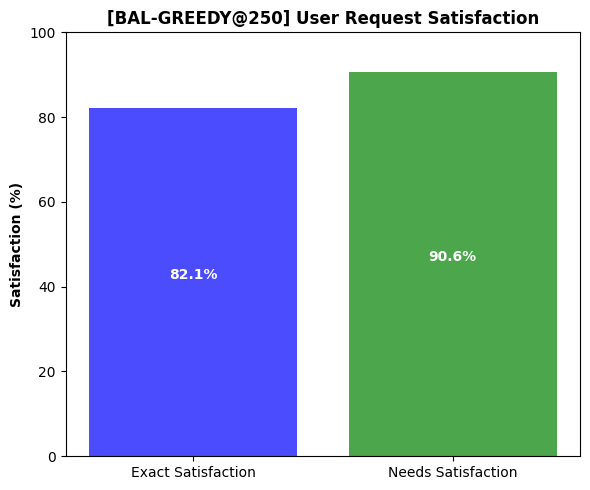

In [134]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

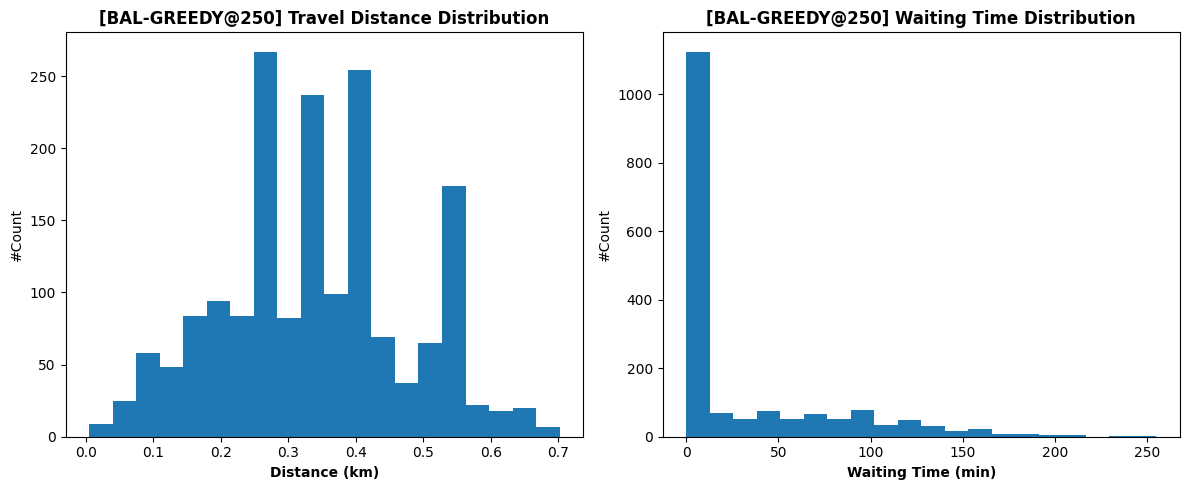

In [135]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

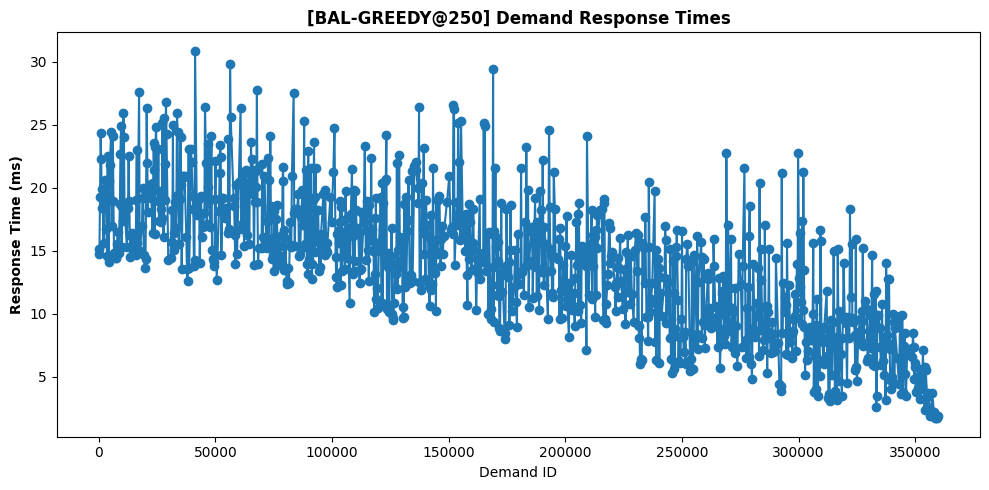

In [136]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

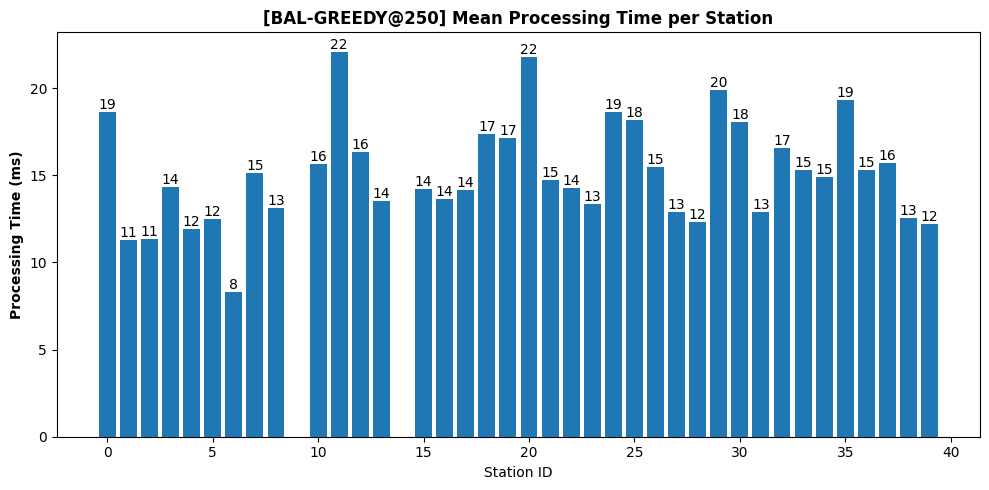

In [137]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [138]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/bramev/250cars


##### *Initialisation*

In [139]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [140]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:40:04.099 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-30 16:40:12.824 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-30 16:40:17.002 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-30 16:40:18.815 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-30 16:40:21.056 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-30 16:40:23.322 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-30 16:40:25.904 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-30 16:40:28.235 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-30 16:40:30.028 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-30 16:40:32.530 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-30 16:40:33.964 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [141]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 220.55 kWh
  Station 1: 65.97 kWh
  Station 2: 39.22 kWh
  Station 3: 52.33 kWh
  Station 4: 81.92 kWh
  Station 5: 99.08 kWh
  Station 6: 206.35 kWh
  Station 7: 1.75 kWh
  Station 8: 67.17 kWh
  Station 9: 26.64 kWh
  Station 10: 37.06 kWh
  Station 11: 31.28 kWh
  Station 12: 50.10 kWh
  Station 13: 113.67 kWh
  Station 14: 13.91 kWh
  Station 15: 16.44 kWh
  Station 16: 8.03 kWh
  Station 17: 62.11 kWh
  Station 18: 129.78 kWh
  Station 19: 91.45 kWh
  Station 20: 192.33 kWh
  Station 21: 71.42 kWh
  Station 22: 63.68 kWh
  Station 23: 20.02 kWh
  Station 24: 231.07 kWh
  Station 25: 67.74 kWh
  Station 26: 44.21 kWh
  Station 27: 62.05 kWh
  Station 28: 91.75 kWh
  Station 29: 40.61 kWh
  Station 30: 24.12 kWh
  Station 31: 121.53 kWh
  Station 32: 46.74 kWh
  Station 33: 15.50 kWh
  Station 34: 8.79 kWh
  Station 35: 35.94 kWh
  Station 36: 106.83 kWh
  Station 37: 6.08 kWh
  Station 38: 21.89 kWh
  Stati

In [142]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

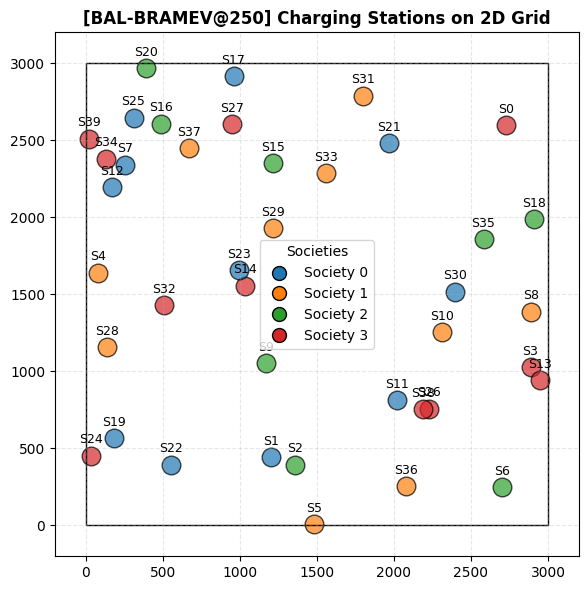

In [143]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

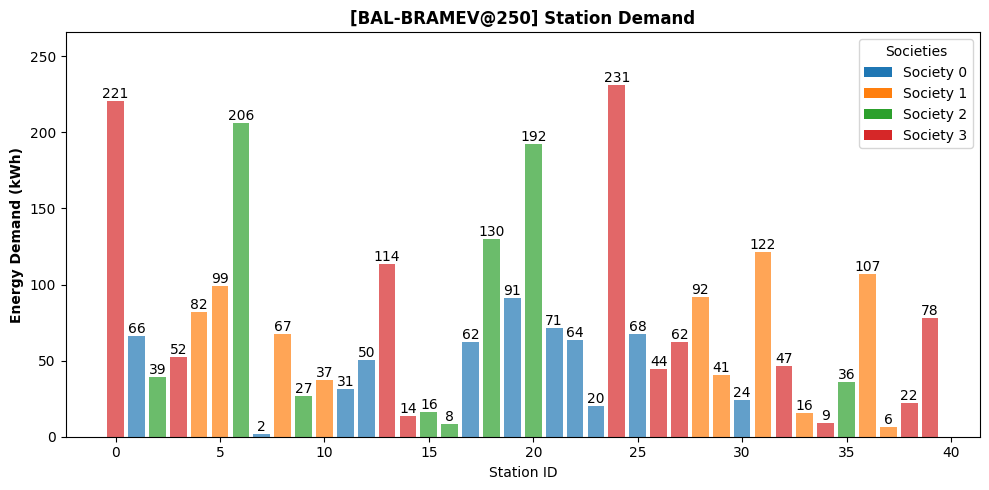

In [144]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

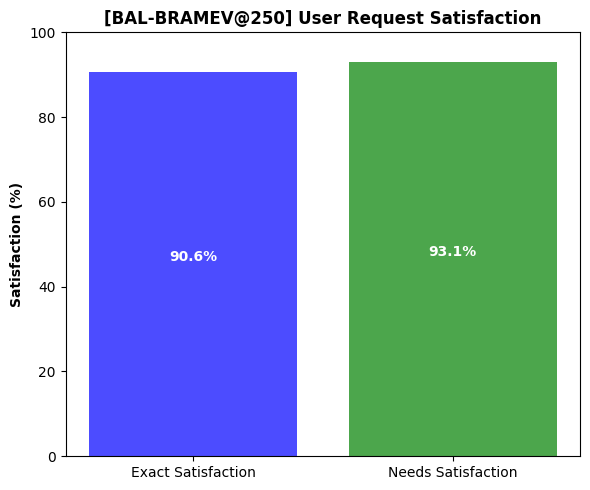

In [145]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

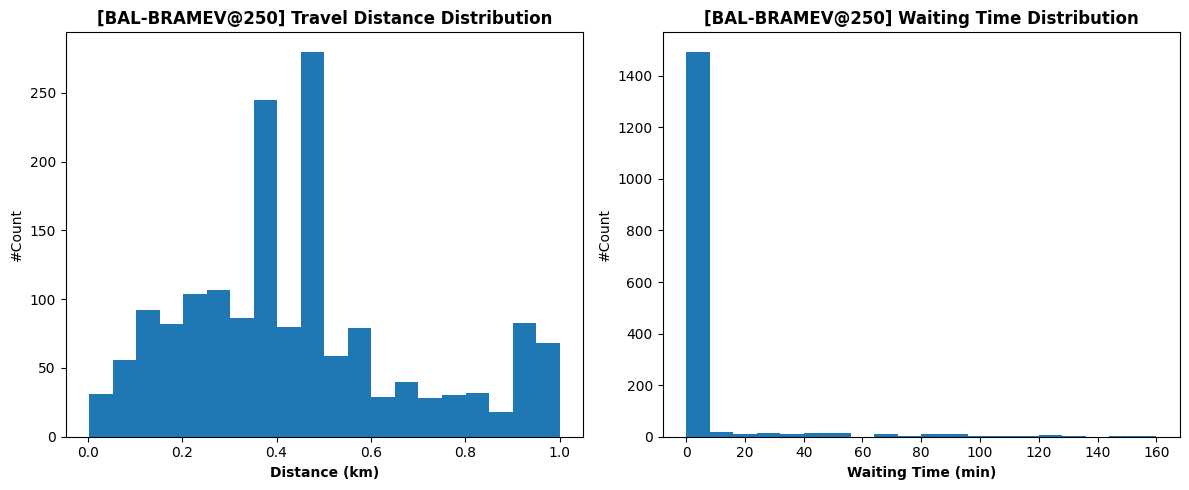

In [146]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

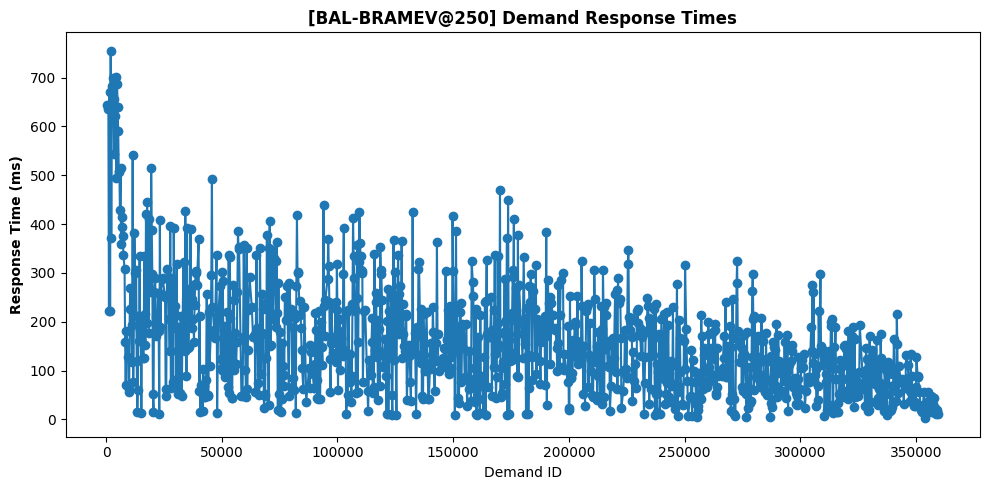

In [147]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

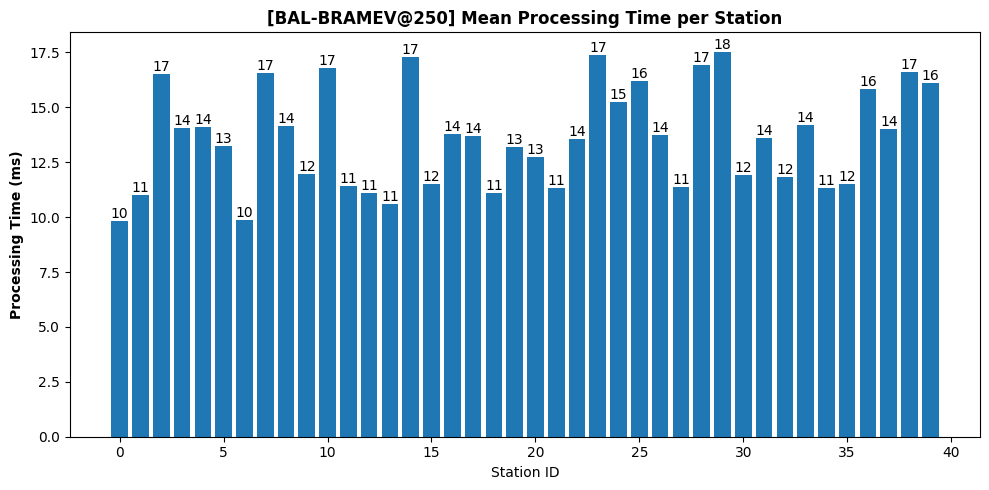

In [148]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

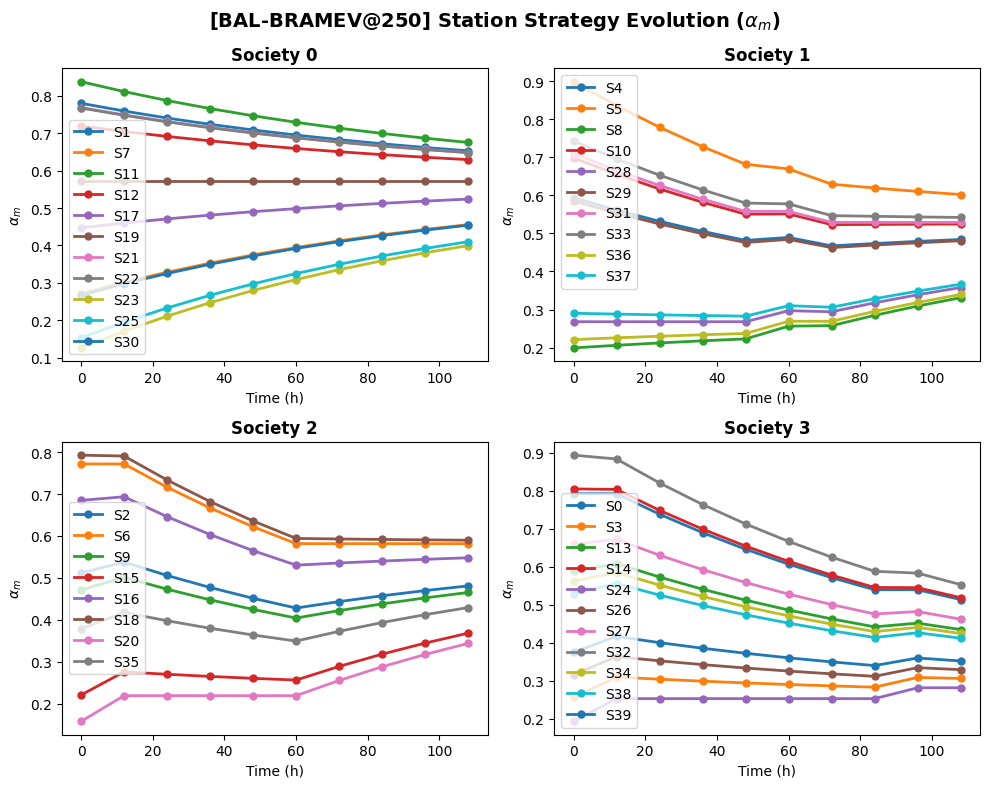

In [149]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [150]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

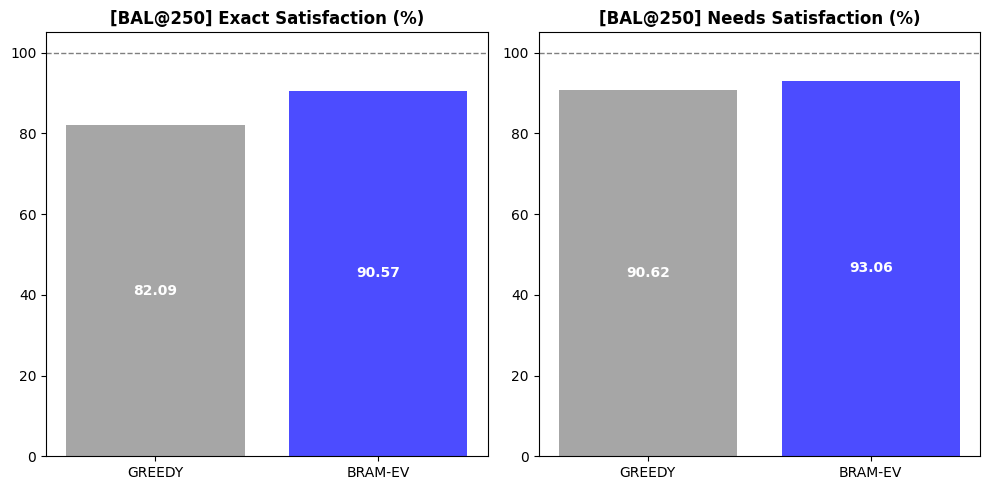

In [151]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

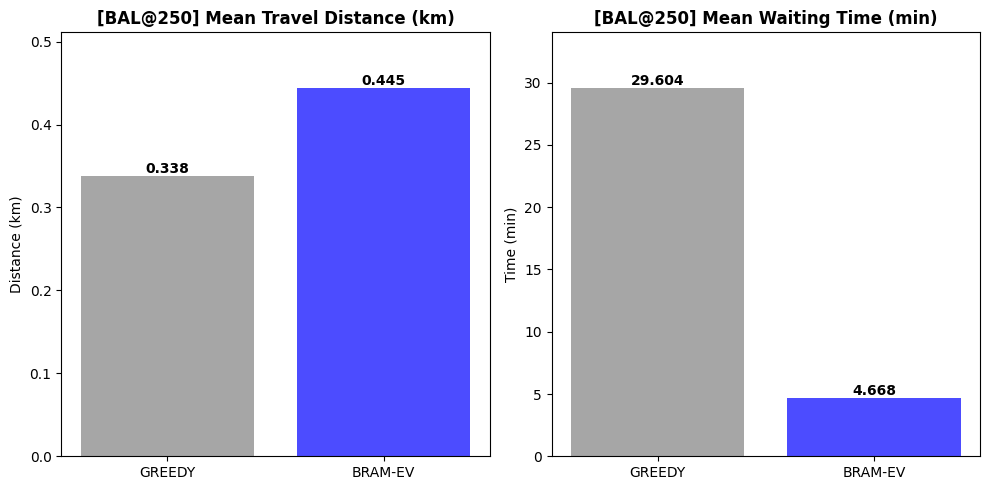

In [152]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

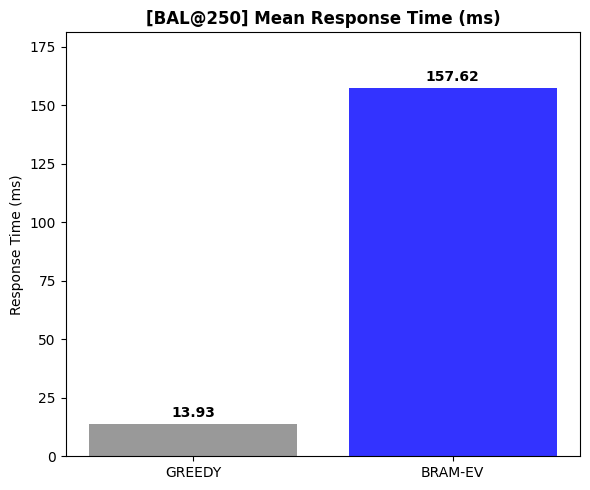

In [153]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

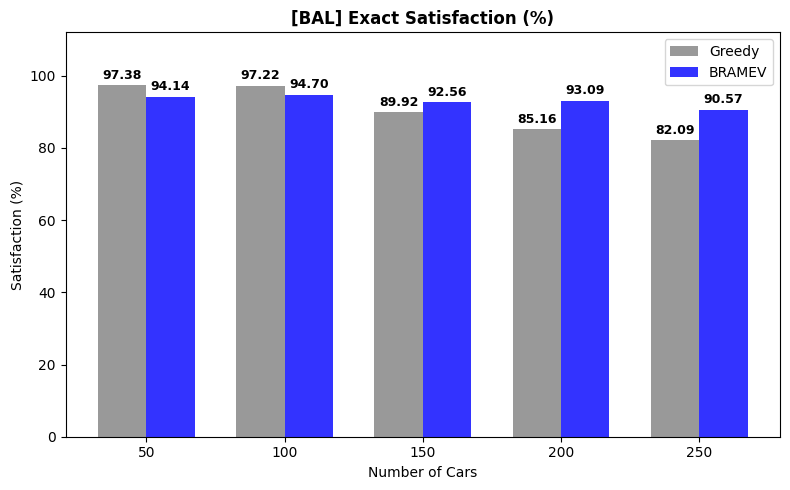

In [154]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

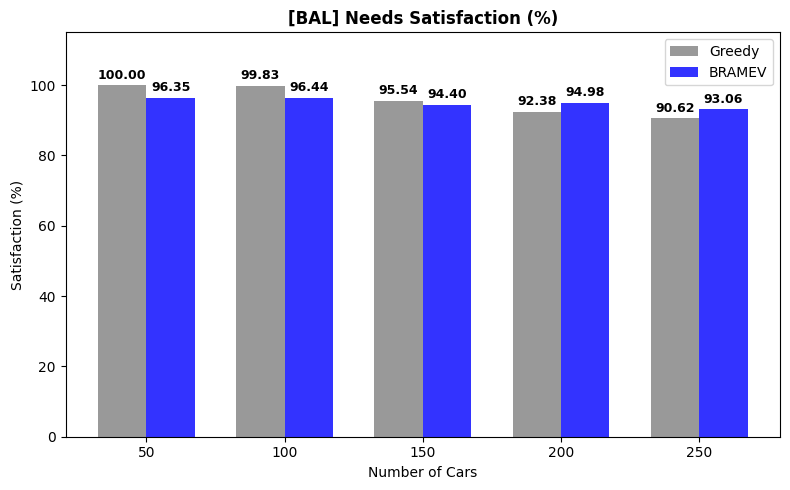

In [155]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

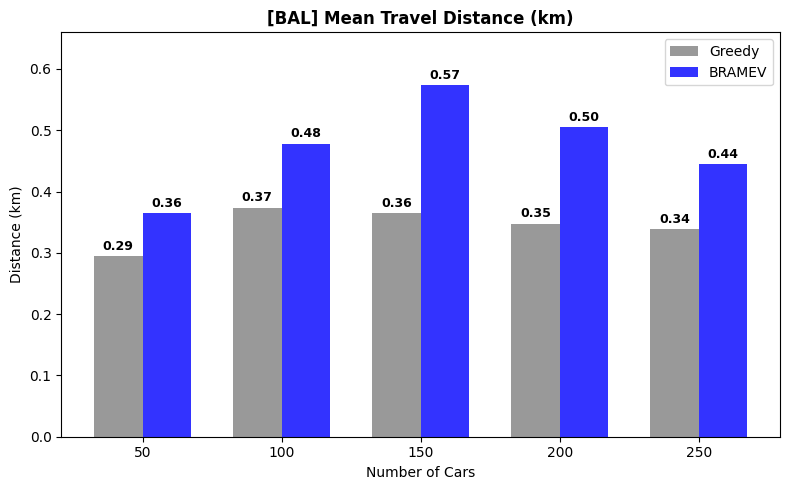

In [156]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


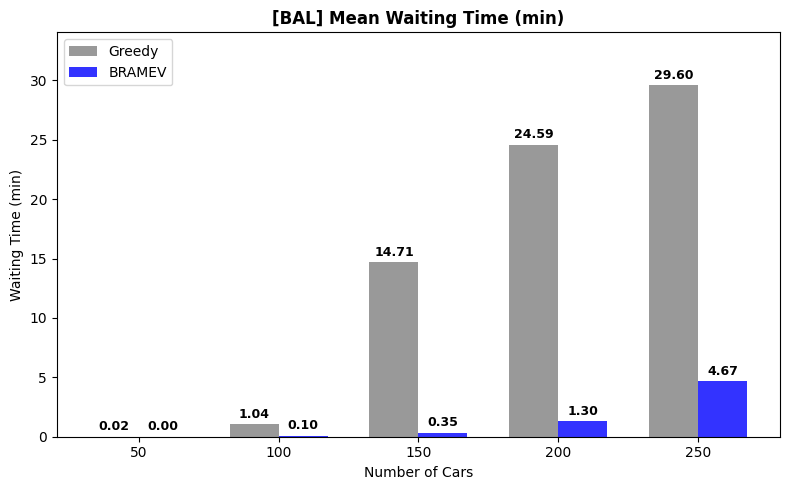

In [157]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


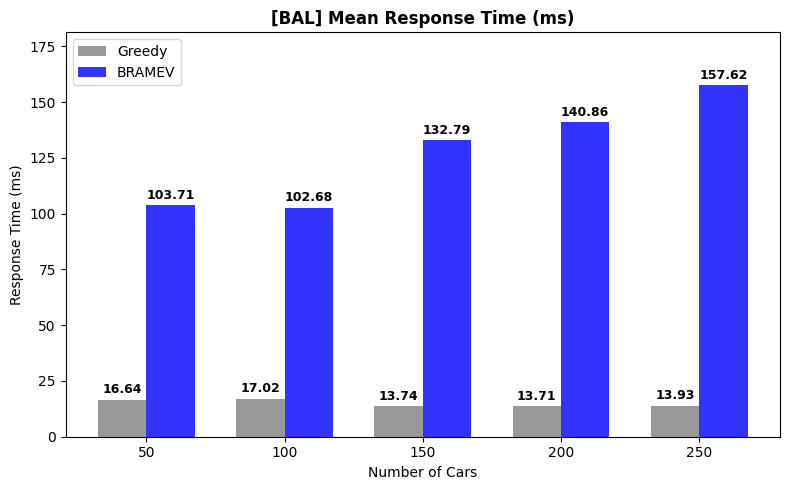

In [158]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
